<a href="https://colab.research.google.com/github/inigo99/CancerDetection/blob/main/TFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM Detección de cáncer en mamografías

Íñigo Fernández Barrill

### Introducción

In [1]:
from IPython.display import clear_output

!wget https://unirioja-my.sharepoint.com/:u:/g/personal/infernb_unirioja_es/EbUEV-DxkwdClaZ4O8w6tOQB727Kg1Q9cQzyheUb7NddSA?download=1 -O Mamografias.zip
!unzip Mamografias.zip
clear_output()

In [2]:
!pip install fastai -Uq
!pip install timm -Uq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.8/236.8 kB 29.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 67.4 MB/s eta 0:00:00


In [3]:
import fastai
from fastai import *
from fastai.vision import *
from fastai.vision.all import *
from fastai.losses import MSELossFlat, CrossEntropyLossFlat
import timm
import PIL
from torchvision import transforms

path = Path('rsna-breast-cancer-detection_reducido_v2/')
imagesPath = path/'train_images'

In [4]:
import pandas as pd

df = pd.read_csv("rsna-breast-cancer-detection_reducido_v2/train.csv")

In [5]:
def cadena(path):
    partes = path.split(os.path.sep)
    return partes[-1][:-4]

def label_func(fname):
    return df.loc[df['image_id'] == int(cadena(fname.name))]['cancer'].values[0]

## Modelos

### Resnet 50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=128)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='modelResnet50')
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

SuggestedLRs(valley=0.004365158267319202)

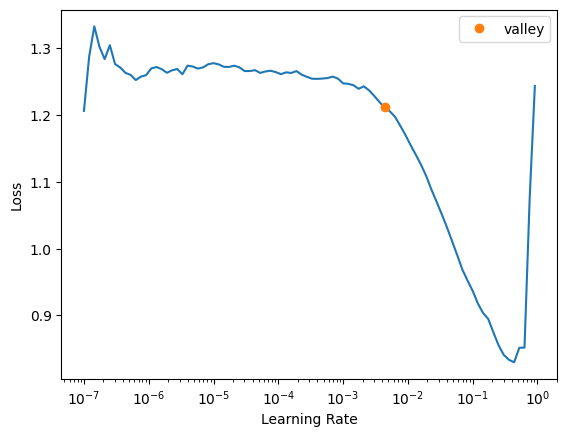

In [ ]:
learn.lr_find()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.134718,0.111616,0.977699,0.000000,0.000000,0.000000,08:48


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.11161649227142334.


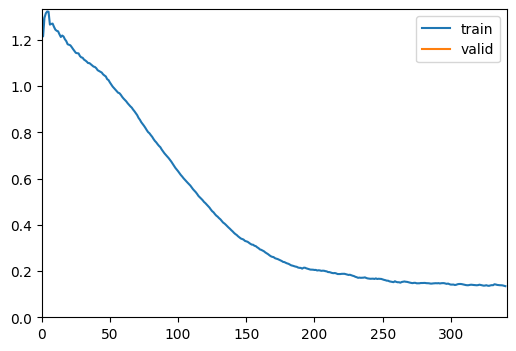

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.105737,0.135013,0.977699,0.000000,0.000000,0.000000,09:04
1,0.113950,0.282286,0.977699,0.000000,0.000000,0.000000,09:04
2,0.112792,0.106755,0.977699,0.000000,0.000000,0.000000,09:10
3,0.099973,0.108033,0.977699,0.000000,0.000000,0.000000,09:09
4,0.098181,0.109675,0.977699,0.000000,0.000000,0.000000,09:02
5,0.098691,0.103121,0.977699,0.000000,0.000000,0.000000,08:51
6,0.096698,0.097624,0.977699,0.500000,0.004098,0.008130,08:40
7,0.089409,0.101533,0.977424,0.440000,0.045082,0.081784,08:49
8,0.088965,0.099235,0.977333,0.437500,0.057377,0.101449,09:03
9,0.088852,0.097297,0.977699,0.500000,0.036885,0.068702,08:59


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.1350134015083313.


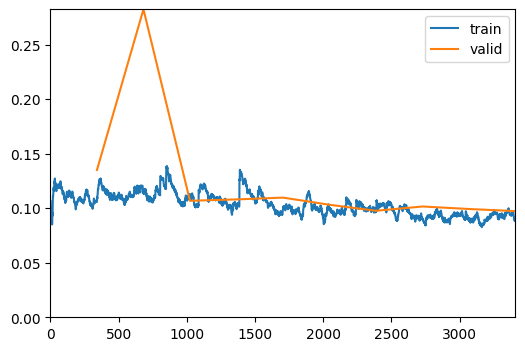

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.10675548017024994.


/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 5 with valid_loss value: 0.10312093794345856.
Better model found at epoch 6 with valid_loss value: 0.09762357920408249.
Better model found at epoch 9 with valid_loss value: 0.09729737788438797.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 40 mins.

### EfficientNet

Para que la ejecució quepa en la caché, hay que reducir los tamaños de las imágenes y el batch.

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=64)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='efficientNetB3')
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [ ]:
import torch
torch.cuda.empty_cache()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.157429,0.123083,0.979527,0.000000,0.000000,0.000000,09:34


Better model found at epoch 0 with valid_loss value: 0.12308338284492493.


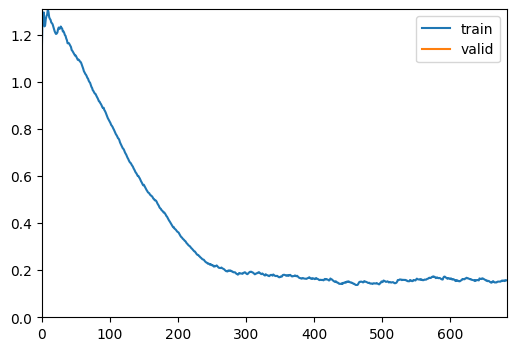

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.109194,0.098137,0.980441,0.000000,0.000000,0.000000,09:29
1,0.114298,0.099628,0.980441,0.000000,0.000000,0.000000,09:19
2,0.125833,0.099406,0.980441,0.000000,0.000000,0.000000,09:17
3,0.109041,0.095146,0.980441,0.000000,0.000000,0.000000,09:16
4,0.103849,0.098076,0.980441,0.000000,0.000000,0.000000,09:19
5,0.088844,0.095915,0.980441,0.000000,0.000000,0.000000,09:19
6,0.107047,nan,0.980441,0.000000,0.000000,0.000000,09:19
7,0.106938,nan,0.980441,0.000000,0.000000,0.000000,09:28
8,0.091529,0.092460,0.980441,0.000000,0.000000,0.000000,09:36
9,0.101932,0.092285,0.980441,0.000000,0.000000,0.000000,09:33


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.09813690185546875.


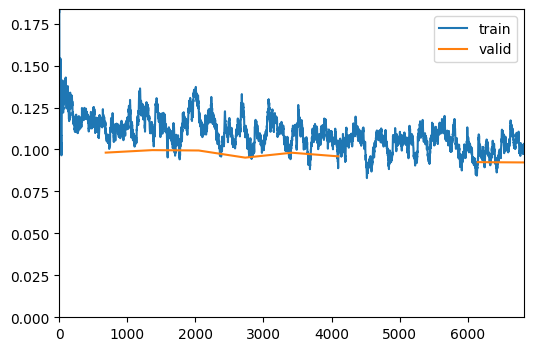

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.09514576196670532.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defin

Better model found at epoch 8 with valid_loss value: 0.09245970100164413.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 9 with valid_loss value: 0.09228470921516418.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 44 mins.

### ConvNext

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='ConvNext')
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=64)

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:07<00:00, 45.9MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.154840,0.114093,0.980258,0.000000,0.000000,0.000000,09:11


Better model found at epoch 0 with valid_loss value: 0.11409283429384232.


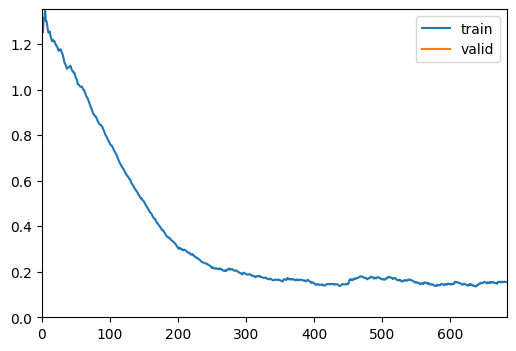

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.097386,0.097244,0.980441,0.000000,0.000000,0.000000,09:37
1,0.124461,0.116928,0.980441,0.000000,0.000000,0.000000,09:37
2,0.101866,0.100506,0.980441,0.000000,0.000000,0.000000,09:35
3,0.108117,0.091792,0.980441,0.000000,0.000000,0.000000,09:36
4,0.100571,0.094839,0.980441,0.000000,0.000000,0.000000,09:36
5,0.107470,0.090112,0.980441,0.000000,0.000000,0.000000,09:37
6,0.107873,0.088212,0.980898,0.857143,0.028037,0.054299,09:39
7,0.106709,0.086807,0.980532,0.538462,0.032710,0.061674,09:30
8,0.096510,0.085968,0.980898,0.857143,0.028037,0.054299,09:29
9,0.099173,0.086072,0.980623,0.600000,0.028037,0.053571,09:28


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.09724444150924683.


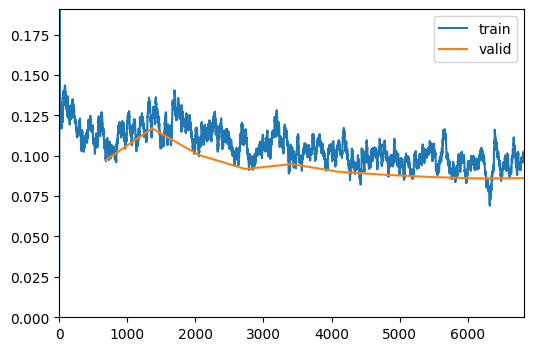

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 3 with valid_loss value: 0.09179195761680603.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 5 with valid_loss value: 0.09011197090148926.
Better model found at epoch 6 with valid_loss value: 0.08821216225624084.
Better model found at epoch 7 with valid_loss value: 0.08680716902017593.
Better model found at epoch 8 with valid_loss value: 0.08596846461296082.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h 45 mins.

### Hrnet

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Hrnet')
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(256),
                 batch_tfms=aug_transforms(size=128,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=32)

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-hrnet/hrnetv2_w44-c9ac8c18.pth" to /root/.cache/torch/hub/checkpoints/hrnetv2_w44-c9ac8c18.pth


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.144876,0.131406,0.976236,0.000000,0.000000,0.000000,12:44


Better model found at epoch 0 with valid_loss value: 0.13140591979026794.


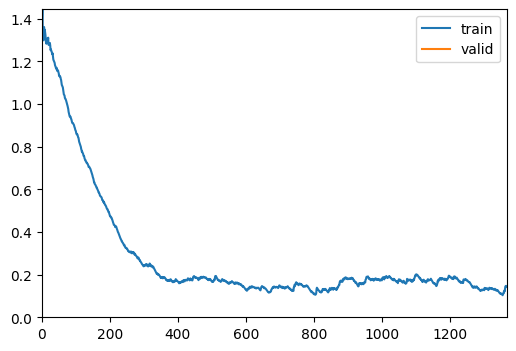

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.099613,0.123273,0.976328,0.000000,0.000000,0.000000,14:00
1,0.126929,0.126066,0.976328,0.000000,0.000000,0.000000,14:00
2,0.118984,0.112464,0.976328,0.000000,0.000000,0.000000,14:10
3,0.114417,0.116200,0.976328,0.000000,0.000000,0.000000,13:59
4,0.103200,0.240522,0.974043,0.000000,0.000000,0.000000,13:58
5,0.095524,1.490318,0.974500,0.000000,0.000000,0.000000,13:55
6,0.101700,nan,0.976328,0.000000,0.000000,0.000000,13:54
7,0.073411,nan,0.976510,0.625000,0.019305,0.037453,13:52
8,0.094232,0.105128,0.976419,0.555556,0.019305,0.037313,13:52
9,0.097534,nan,0.976510,0.625000,0.019305,0.037453,13:50


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 0 with valid_loss value: 0.12327256053686142.


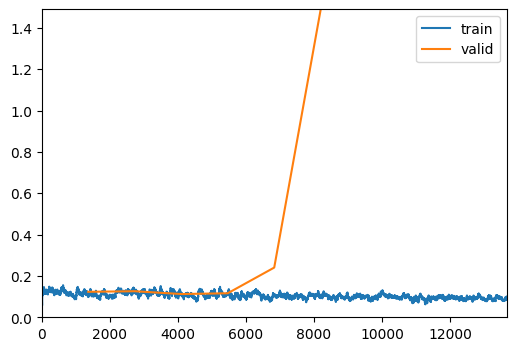

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 2 with valid_loss value: 0.11246427148580551.


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Better model found at epoch 8 with valid_loss value: 0.10512750595808029.


In [ ]:
learn.fine_tune(10, base_lr=1e-2)

2 horas 33 minutos.

### Deit

In [ ]:
callbacks = [
    ShowGraphCallback(),
    SaveModelCallback(fname='Deit')
]

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(384), # Solo funciona con este tamaño
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(imagesPath, bs=8)

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

In [ ]:
learn.fine_tune(10, base_lr=1e-2)

Ha tardado 1h solo en la primera época, por lo que se espera que tarde 10 horas.

## Balanceo

In [6]:
df

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54701,1,9973,1729524723,R,MLO,43.0,0,0,0,1.0,0,C,49,False
54702,1,9989,63473691,L,MLO,60.0,0,0,0,NaN,0,C,216,False
54703,1,9989,1078943060,L,CC,60.0,0,0,0,NaN,0,C,216,False
54704,1,9989,398038886,R,MLO,60.0,0,0,0,0.0,0,C,216,True


In [7]:
tam = df.loc[df["cancer"] == 1]["patient_id"].unique().size

In [8]:
X = df.loc[::, df.columns.drop("cancer")].copy()
y = df.loc[::, "cancer"].copy()

In [9]:
y.value_counts()

0    53548
1     1158
Name: cancer, dtype: int64

Los datos están claramente desbalanceados. Se va a escoger al azar los elementos de la clase mayoritaria para entrenar a los modelos.

In [10]:
np.random.seed(0)
patients = np.random.choice(df.loc[df["cancer"] == 0]["patient_id"], tam)
patients = np.concatenate((patients, df.loc[df["cancer"] == 1]["patient_id"].unique()))
patients.size

972

In [11]:
dfb = df.loc[df["patient_id"].isin(patients)].copy()

In [12]:
dfb

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
87,1,10130,388811999,L,MLO,71.0,1,1,1,0.0,0,B,49,False
88,1,10130,613462606,L,CC,71.0,1,1,1,0.0,0,B,49,False
89,1,10130,1360338805,L,CC,71.0,1,1,1,0.0,0,B,49,False
90,1,10130,1672636630,L,MLO,71.0,1,1,1,0.0,0,B,49,False
91,1,10130,1013166704,R,CC,71.0,0,0,0,NaN,0,B,49,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54598,2,9851,1945262248,R,MLO,58.0,0,0,0,NaN,0,NaN,48,False
54625,1,9894,564726178,L,CC,50.0,0,1,0,0.0,0,B,49,True
54626,1,9894,942623950,L,MLO,50.0,0,1,0,0.0,0,B,49,True
54627,1,9894,1991772614,R,CC,50.0,0,1,0,0.0,0,B,49,True


In [13]:
import os
import shutil

p_under = path/"undersampled"

if not os.path.isdir(p_under):
    os.mkdir(p_under)

for index, row in dfb.iterrows():
    patient = row["patient_id"]
    shutil.copytree(imagesPath/str(patient), p_under/str(patient), dirs_exist_ok=True)

In [14]:
def cadena2(path):
    partes = path.split(os.path.sep)
    return partes[0][:-4]

def label_func2(fname):
    return dfb.loc[dfb['image_id'] == int(cadena2(fname.name))]['cancer'].values[0]

## Modelos undersampling

### Resnet50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=32)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='modelResnet50')
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.182381,0.684254,0.675764,0.282178,0.272727,0.277372,01:14


Better model found at epoch 0 with valid_loss value: 0.6842542290687561.


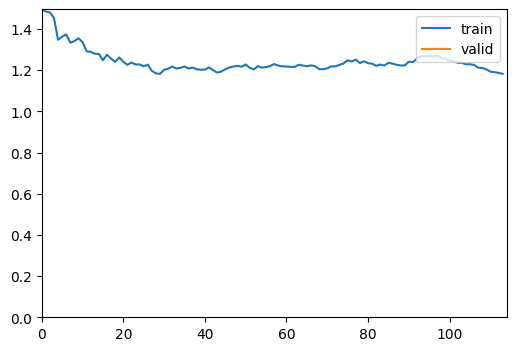

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.861584,0.600201,0.740175,0.340659,0.148325,0.206667,01:25
1,0.809583,0.651712,0.770742,0.400000,0.009569,0.018692,01:26
2,0.750382,0.548378,0.763100,0.404762,0.081340,0.135458,01:26
3,0.719044,0.580735,0.771834,0.500000,0.004785,0.009479,01:25


Better model found at epoch 0 with valid_loss value: 0.6002006530761719.


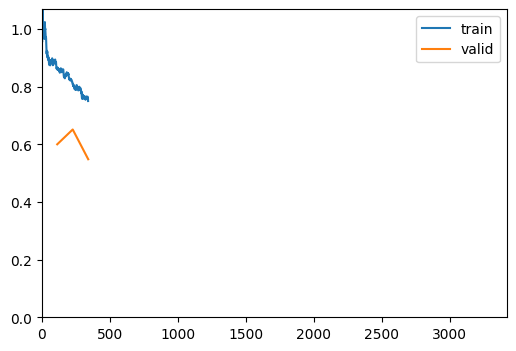

Better model found at epoch 2 with valid_loss value: 0.5483778119087219.
No improvement since epoch 0: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

Ha tardado 7 mins.

### EfficientNet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='efficientNetB3')
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-cf984f9c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-cf984f9c.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 73.2MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.074252,nan,0.757642,0.333333,0.062201,0.104839,01:35


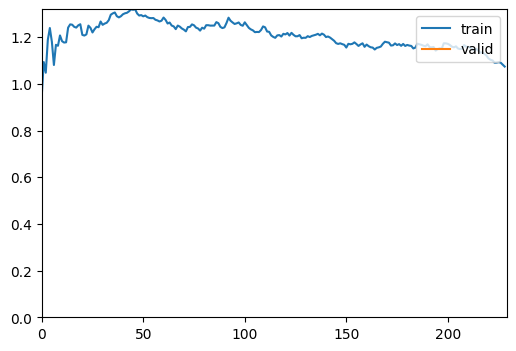

FileNotFoundError: ignored

In [ ]:
learn.fine_tune(30, base_lr=1e-3)

No sé por qué no funciona.

### ConvNext

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='ConvNext')
]

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:06<00:00, 54.8MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.041896,0.739255,0.742358,0.333333,0.129187,0.186207,03:09


Better model found at epoch 0 with valid_loss value: 0.7392553091049194.


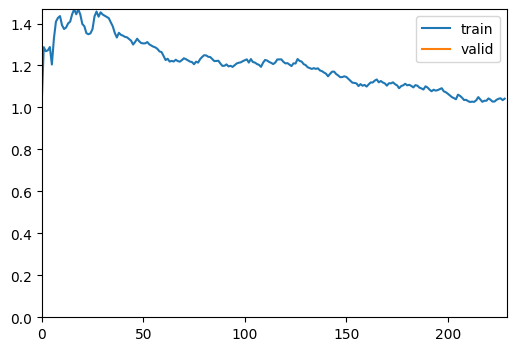

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.803352,0.641517,0.776201,0.562500,0.086124,0.149378,03:58
1,0.771936,0.561804,0.730349,0.360294,0.234450,0.284058,03:58
2,0.725425,0.686403,0.777293,1.000000,0.023923,0.046729,03:58
3,0.750516,0.557713,0.757642,0.372549,0.090909,0.146154,03:58
4,0.670676,0.650633,0.776201,0.833333,0.023923,0.046512,03:58


Better model found at epoch 0 with valid_loss value: 0.6415166258811951.


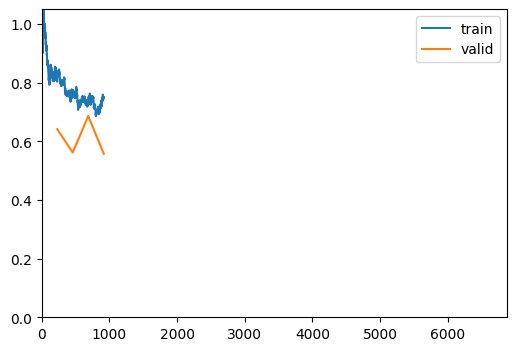

Better model found at epoch 1 with valid_loss value: 0.561804473400116.
Better model found at epoch 3 with valid_loss value: 0.5577128529548645.
No improvement since epoch 1: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

Ha tardado 23 minutos.

### Hrnet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Hrnet')
]

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.931272,0.715426,0.732533,0.290698,0.119617,0.169492,04:42


Better model found at epoch 0 with valid_loss value: 0.7154256105422974.


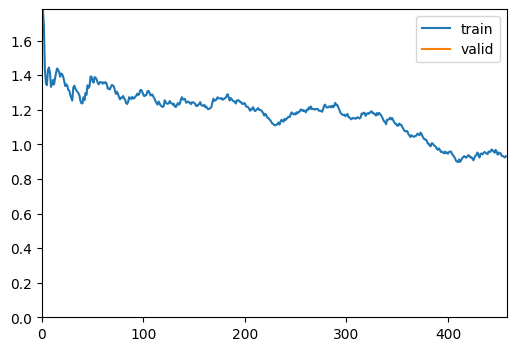

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.701617,0.577592,0.741266,0.337209,0.138756,0.196610,06:16
1,0.698727,0.561044,0.735808,0.305882,0.124402,0.176871,06:16
2,0.656262,0.551533,0.768559,0.285714,0.009569,0.018519,06:17
3,0.629854,0.571239,0.695415,0.208333,0.119617,0.151976,06:17


Better model found at epoch 0 with valid_loss value: 0.5775920748710632.


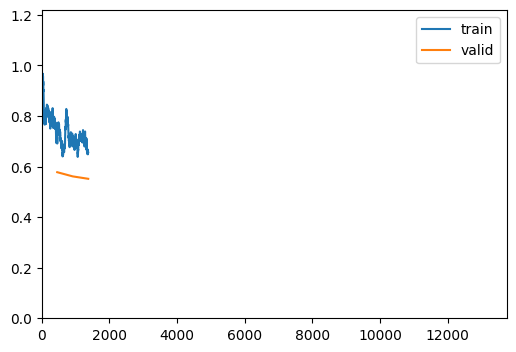

Better model found at epoch 1 with valid_loss value: 0.5610436797142029.
Better model found at epoch 2 with valid_loss value: 0.5515329837799072.
No improvement since epoch 0: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

30 minutos.

### Deit

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func2,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Deit')
]

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.981733,0.662352,0.705240,0.292517,0.205742,0.241573,01:44


Better model found at epoch 0 with valid_loss value: 0.662351667881012.


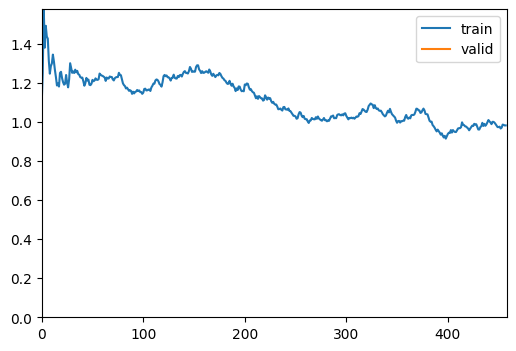

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.721167,0.557858,0.754367,0.421569,0.205742,0.276527,02:21
1,0.715758,0.558038,0.733624,0.364341,0.224880,0.278107,02:21
2,0.648156,0.552422,0.757642,0.432990,0.200957,0.274510,02:21
3,0.649120,0.559785,0.736900,0.387324,0.263158,0.313390,02:21
4,0.594278,0.533125,0.759825,0.447619,0.224880,0.299363,02:22
5,0.574233,0.508104,0.768559,0.483516,0.210526,0.293333,02:21
6,0.573295,0.505712,0.767467,0.486667,0.349282,0.406685,02:22
7,0.581476,0.520290,0.767467,0.487952,0.387560,0.432000,02:20
8,0.567518,0.483228,0.802402,0.600000,0.401914,0.481375,02:21
9,0.497354,0.483892,0.783843,0.542636,0.334928,0.414201,02:21


Better model found at epoch 0 with valid_loss value: 0.557857871055603.


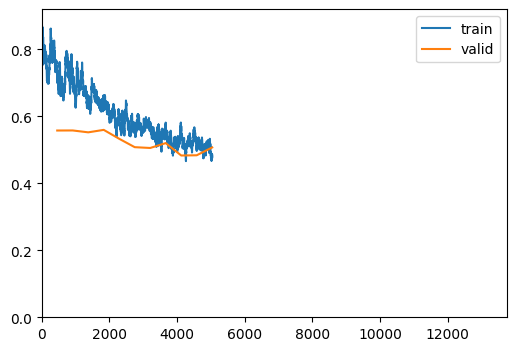

Better model found at epoch 2 with valid_loss value: 0.5524224638938904.
Better model found at epoch 4 with valid_loss value: 0.5331253409385681.
Better model found at epoch 5 with valid_loss value: 0.508103609085083.
Better model found at epoch 6 with valid_loss value: 0.50571209192276.
Better model found at epoch 8 with valid_loss value: 0.4832279682159424.
Better model found at epoch 11 with valid_loss value: 0.47656822204589844.
No improvement since epoch 8: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

30 minutos.

## Balanceo v2

Esta vez se a a probar a balancear por imagenes en vez de por pacientes a ver qué ocurre.

In [15]:
tam = df.loc[df["cancer"] == 1]["image_id"].size

In [16]:
np.random.seed(0)
images = df.loc[df["cancer"] == 1]["image_id"]
images = np.concatenate((images, np.random.choice(df.loc[df["cancer"] == 0]["image_id"], tam)))
images.size

2316

In [17]:
dfb2 = df.loc[df["image_id"].isin(images)].copy()

In [18]:
dfb2["cancer"].value_counts()

1    1158
0    1147
Name: cancer, dtype: int64

In [19]:
import os
import shutil

p_under2 = path/"undersampled_v2"

if not os.path.isdir(p_under2):
    os.mkdir(p_under2)

for index, row in dfb2.iterrows():
    patient = row["patient_id"]
    if not os.path.isdir(p_under2/str(patient)):
        os.mkdir(p_under2/str(patient))
    image = row["image_id"]
    src = imagesPath/str(patient)/(str(image)+'.jpg')
    dst = p_under2/str(patient)/(str(image)+'.jpg')
    shutil.copyfile(src, dst)

In [20]:
def cadena3(path):
    partes = path.split(os.path.sep)
    return partes[0][:-4]

def label_func3(fname):
    return dfb2.loc[dfb2['image_id'] == int(cadena3(fname.name))]['cancer'].values[0]

## Modelos undersampling v2

### Resnet50

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=32)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='modelResnet50')
]

In [ ]:
learn = vision_learner(dls, resnet50, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.319444,2.047321,0.537961,0.530892,0.966667,0.685377,00:42


Better model found at epoch 0 with valid_loss value: 2.04732084274292.


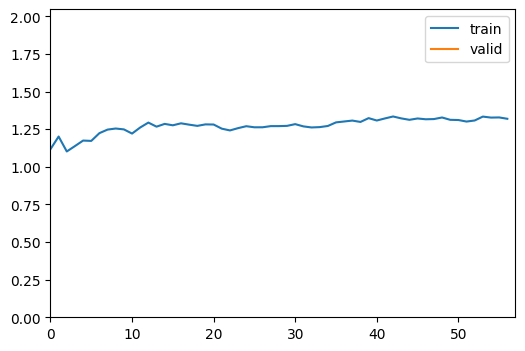

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.067761,0.924267,0.563991,0.572491,0.641667,0.605108,00:42
1,1.043945,0.798499,0.574837,0.588710,0.608333,0.598361,00:43
2,0.964636,0.886527,0.503254,0.522088,0.541667,0.531697,00:45
3,0.939635,0.873033,0.531453,0.600000,0.300000,0.400000,00:43


Better model found at epoch 0 with valid_loss value: 0.9242668747901917.


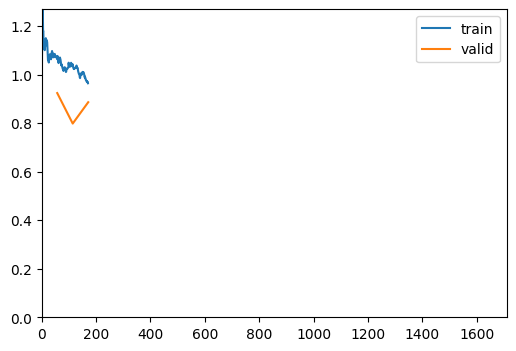

Better model found at epoch 1 with valid_loss value: 0.7984985709190369.
No improvement since epoch 0: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

Ha tardado 3 minutos y medio.

### EfficientNet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='efficientNetB3')
]

In [ ]:
learn = vision_learner(dls, efficientnet_b3, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-cf984f9c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-cf984f9c.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 69.5MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.315400,nan,0.464208,0.347826,0.033333,0.060837,00:50


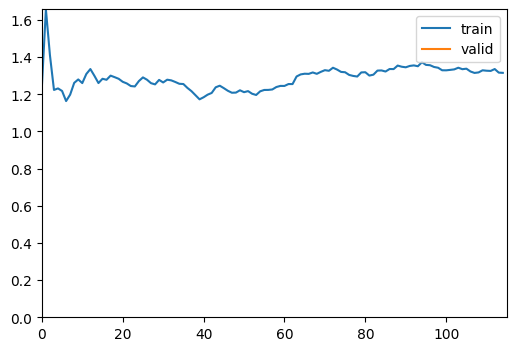

FileNotFoundError: ignored

In [ ]:
learn.fine_tune(30, base_lr=1e-3)

Sigue dando error.

### ConvNext

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=16)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='ConvNext')
]

In [ ]:
learn = vision_learner(dls, convnext_base, metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:04<00:00, 79.1MB/s]


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.376362,1.009986,0.557484,0.572581,0.591667,0.581967,01:37


Better model found at epoch 0 with valid_loss value: 1.0099855661392212.


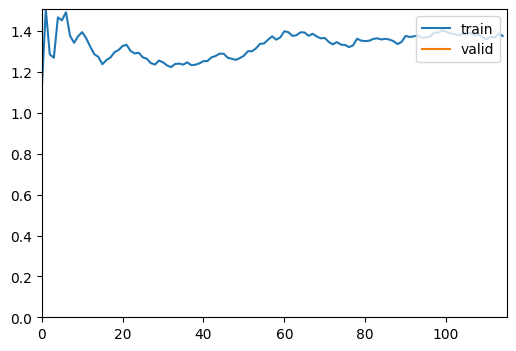

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.099999,0.809445,0.587852,0.587413,0.700000,0.638783,02:02
1,1.044641,0.742330,0.603037,0.610039,0.658333,0.633267,02:03
2,0.972508,0.784720,0.596529,0.585443,0.770833,0.665468,02:03
3,0.988065,0.710840,0.600868,0.595890,0.725000,0.654135,02:02
4,0.942924,0.692587,0.596529,0.616379,0.595833,0.605932,02:03
5,0.915726,0.692445,0.603037,0.589342,0.783333,0.672630,02:03
6,0.849702,0.791567,0.590022,0.573066,0.833333,0.679117,02:02
7,0.809494,0.681677,0.611714,0.591592,0.820833,0.687609,02:02
8,0.791373,0.701945,0.587852,0.630208,0.504167,0.560185,02:02
9,0.766636,0.647140,0.609544,0.611111,0.687500,0.647059,02:03


Better model found at epoch 0 with valid_loss value: 0.8094454407691956.


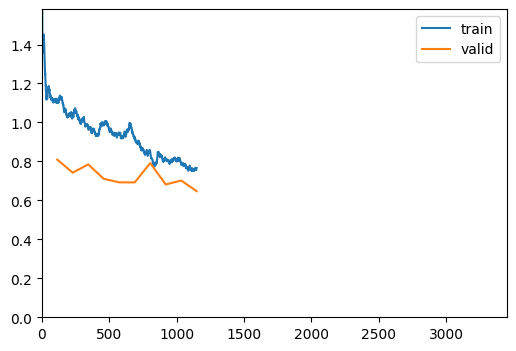

Better model found at epoch 1 with valid_loss value: 0.7423302531242371.
Better model found at epoch 3 with valid_loss value: 0.710840106010437.
Better model found at epoch 4 with valid_loss value: 0.6925873756408691.
Better model found at epoch 5 with valid_loss value: 0.6924451589584351.
Better model found at epoch 7 with valid_loss value: 0.6816770434379578.
Better model found at epoch 9 with valid_loss value: 0.6471402645111084.
No improvement since epoch 7: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

Ha tardado 25 minutos.

### Hrnet

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Hrnet')
]

In [ ]:
learn = vision_learner(dls, 'hrnet_w44', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.271210,0.992572,0.559653,0.588517,0.512500,0.547884,02:23


Better model found at epoch 0 with valid_loss value: 0.9925723075866699.


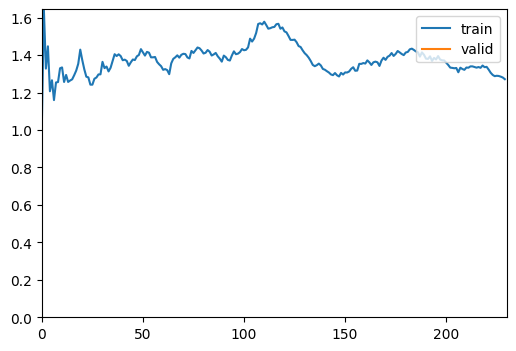

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.167208,0.990542,0.511931,0.568807,0.258333,0.355301,03:08
1,1.060144,0.877576,0.505423,0.536585,0.366667,0.435644,03:10
2,0.997342,0.825949,0.537961,0.570681,0.454167,0.505800,03:10
3,0.961307,0.859933,0.583514,0.600000,0.600000,0.600000,03:09
4,0.898518,0.776846,0.553145,0.577273,0.529167,0.552174,03:09
5,0.822037,0.714520,0.568330,0.600985,0.508333,0.550790,03:10
6,0.790439,0.714123,0.524946,0.558659,0.416667,0.477327,03:11


Better model found at epoch 0 with valid_loss value: 0.9905419945716858.


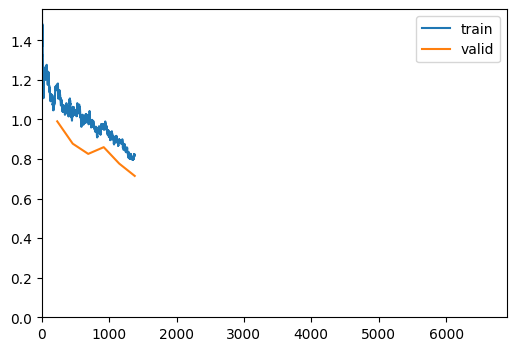

Better model found at epoch 1 with valid_loss value: 0.8775759935379028.
Better model found at epoch 2 with valid_loss value: 0.8259490728378296.
Better model found at epoch 4 with valid_loss value: 0.7768463492393494.
Better model found at epoch 5 with valid_loss value: 0.7145199775695801.
Better model found at epoch 6 with valid_loss value: 0.7141234874725342.
No improvement since epoch 3: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

25 minutos.

### Deit

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

In [ ]:
dls = db.dataloaders(p_under2, bs=8)

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Deit')
]

In [ ]:
learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=[accuracy, Precision(), Recall(), F1Score()], cbs=callbacks).to_fp16()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,1.085783,0.841629,0.553145,0.582524,0.500000,0.538117,00:56


Better model found at epoch 0 with valid_loss value: 0.8416293859481812.


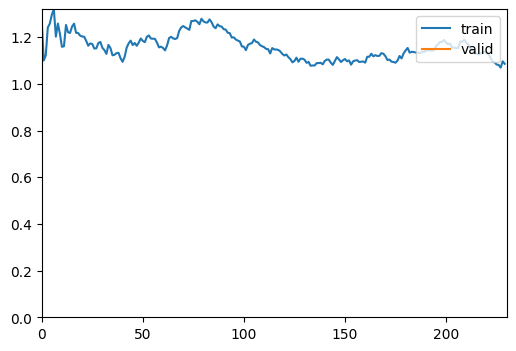

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.948138,0.738734,0.561822,0.593137,0.504167,0.545045,01:13
1,0.948275,0.682456,0.592191,0.600000,0.650000,0.624000,01:13
2,0.841126,0.726983,0.577007,0.596567,0.579167,0.587738,01:15
3,0.910646,0.715202,0.579176,0.630682,0.462500,0.533654,01:13
4,0.807623,0.662178,0.620390,0.643172,0.608333,0.625268,01:13
5,0.786741,0.650281,0.652928,0.694175,0.595833,0.641256,01:13
6,0.731067,0.654595,0.633406,0.678392,0.562500,0.615034,01:13
7,0.648493,0.644583,0.648590,0.657258,0.679167,0.668033,01:13
8,0.628785,0.641841,0.639913,0.677885,0.587500,0.629464,01:11
9,0.650516,0.654436,0.629067,0.648069,0.629167,0.638478,01:11


Better model found at epoch 0 with valid_loss value: 0.738734245300293.


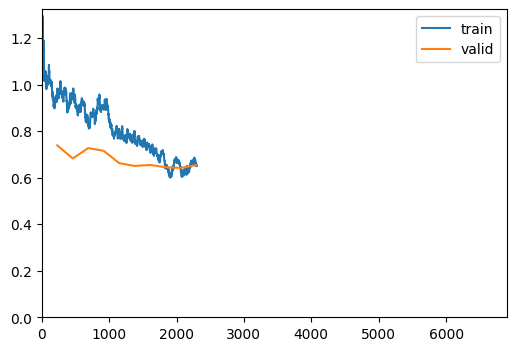

Better model found at epoch 1 with valid_loss value: 0.6824564337730408.
Better model found at epoch 4 with valid_loss value: 0.6621779203414917.
Better model found at epoch 5 with valid_loss value: 0.650280773639679.
Better model found at epoch 7 with valid_loss value: 0.6445826292037964.
Better model found at epoch 8 with valid_loss value: 0.6418411135673523.
Better model found at epoch 10 with valid_loss value: 0.6340940594673157.
No improvement since epoch 7: early stopping


In [ ]:
learn.fine_tune(30, base_lr=1e-3)

14 minutos y medio.

## Multi-Task

In [21]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
dfb2["density"] = enc.fit_transform(np.array(dfb2["density"]).reshape(-1,1))
dfb2["density"]

63       NaN
87       1.0
88       1.0
89       1.0
90       1.0
        ... 
54596    NaN
54599    NaN
54627    1.0
54636    NaN
54642    2.0
Name: density, Length: 2305, dtype: float64

In [22]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=3, weights="uniform")
dfb2[dfb2.columns[5:]] = imputer.fit_transform(dfb2[dfb2.columns[5:]])

In [23]:
dfb2[dfb2.columns[5:]] = dfb2[dfb2.columns[5:]].astype(int)
dfb2

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
63,2,10106,190315990,R,MLO,57,0,0,0,0,0,1,21,0
87,1,10130,388811999,L,MLO,71,1,1,1,0,0,1,49,0
88,1,10130,613462606,L,CC,71,1,1,1,0,0,1,49,0
89,1,10130,1360338805,L,CC,71,1,1,1,0,0,1,49,0
90,1,10130,1672636630,L,MLO,71,1,1,1,0,0,1,49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54596,2,9851,1434430689,L,CC,58,1,1,0,0,0,1,48,0
54599,2,9852,948754725,L,CC,58,0,0,0,0,0,1,29,0
54627,1,9894,1991772614,R,CC,50,0,1,0,0,0,1,49,1
54636,2,990,837618473,R,MLO,57,0,0,0,1,0,1,48,0


In [24]:
label = []
for i, row in dfb2.iterrows():
    edad = str(int(row["age"]))
    cancer = str(row["cancer"])
    densidad = str(row["density"])
    if '.' in densidad:
        densidad = densidad[0]
    label.append(edad + ' ' + cancer + ' ' + densidad)
dfb2["label"] = label
dfb2

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case,label
63,2,10106,190315990,R,MLO,57,0,0,0,0,0,1,21,0,57 0 1
87,1,10130,388811999,L,MLO,71,1,1,1,0,0,1,49,0,71 1 1
88,1,10130,613462606,L,CC,71,1,1,1,0,0,1,49,0,71 1 1
89,1,10130,1360338805,L,CC,71,1,1,1,0,0,1,49,0,71 1 1
90,1,10130,1672636630,L,MLO,71,1,1,1,0,0,1,49,0,71 1 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54596,2,9851,1434430689,L,CC,58,1,1,0,0,0,1,48,0,58 1 1
54599,2,9852,948754725,L,CC,58,0,0,0,0,0,1,29,0,58 0 1
54627,1,9894,1991772614,R,CC,50,0,1,0,0,0,1,49,1,50 0 1
54636,2,990,837618473,R,MLO,57,0,0,0,1,0,1,48,0,57 0 1


In [25]:
class MultiTaskDataset():
    def __init__(self, df, tfms, size=64):
        self.paths = []
        for index, row in df.iterrows():
            patient = row["patient_id"]
            image = row["image_id"]
            path = p_under2/str(patient)/(str(image) + '.jpg')
            self.paths.append(path)
        self.labels = list(df["label"])
        self.tfms = tfms
        self.size = size
        self.train = df.copy()
        self.norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #imagenet stats

    def __len__(self): return len(self.paths)

    def __getitem__(self,idx):
        #dealing with the image
        img = PIL.Image.open(self.paths[idx]).convert('RGB')
        img = img.resize((256, 256))
        t = torch.Tensor(np.array(img))
        t = t.permute(2, 0, 1).float() / 255.0
        transform = transforms.ToPILImage()
        img = PILImage(PILImage.create(transform(t)))
        img = self.tfms.encodes(img)
        transform = transforms.Compose([transforms.ToTensor()])
        img = self.norm(transform(img))
        #dealing with the labels
        labels = self.labels[idx].split(" ")
        age = torch.tensor(float(labels[0]), dtype=torch.float32)
        cancer = torch.tensor(int(labels[1]), dtype=torch.int64)
        density = torch.tensor(int(labels[2]), dtype=torch.int64)

        return img, (age.log_() / 4.489, cancer, density)

    def show(self,idx):
        x, y = self.__getitem__(idx)
        age, cancer, density = y
        stds = np.array([0.229, 0.224, 0.225])
        means = np.array([0.485, 0.456, 0.406])
        img = ((x.numpy().transpose((1, 2, 0)) * stds + means) * 255).astype(np.uint8)
        plt.imshow(img)
        plt.title("{} {} {}".format(int(age.mul_(4.489).exp_().item()), cancer.item(), density.item()))

In [26]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(dfb2, test_size=0.2)

tfms = aug_transforms()
tdset = MultiTaskDataset(train, tfms[0], size=64)
vdset = MultiTaskDataset(test, tfms[1], size=64)
data = DataLoaders.from_dsets(tdset, vdset, batch_size=4, shuffle=True, device=torch.device('cuda'))

In [27]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1024, 1, ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1024, 2, ps=ps)
        self.fc3 = create_head(1024, 4, ps=ps) # 11?

    def forward(self, x):
        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

In [28]:
class MultiTaskLossWrapper(nn.Module):
    def __init__(self, task_num):
        super(MultiTaskLossWrapper, self).__init__()
        self.task_num = task_num
        self.log_vars = nn.Parameter(torch.zeros((task_num)))

    def forward(self, preds, label):

        mse, crossEntropy = MSELossFlat(), CrossEntropyLossFlat()

        loss0 = mse(preds[0], label[0])
        loss1 = crossEntropy(preds[1], label[1])
        loss2 = crossEntropy(preds[2], label[2])

        precision0 = torch.exp(-self.log_vars[0])
        loss0 = precision0 * loss0 + self.log_vars[0]

        precision1 = torch.exp(-self.log_vars[1])
        loss1 = precision1 * loss1 + self.log_vars[1]

        precision2 = torch.exp(-self.log_vars[2])
        loss2 = precision2 * loss2 + self.log_vars[2]

        return 3* (0.1 * loss0 + 0.6 * loss1 + 0.3 * loss2)

In [29]:
from sklearn.metrics import f1_score
def rmse_age(preds, labels): return rmse(preds[0], labels[0])
def f1_cancer(preds, labels):
    pred = preds[1].cpu()
    pred = np.array(pred)
    plist = []
    for i in range(len(pred)):
        if pred[i][0] > pred[i][1]:
            plist.append(1)
        else:
            plist.append(0)
    return f1_score(np.array(plist), labels[1].cpu(), zero_division=0)
def acc_density(preds, labels): return accuracy(preds[2], labels[2])

metrics = [rmse_age, f1_cancer, acc_density]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_func = MultiTaskLossWrapper(3).to(device) #just making sure the loss is on the gpu

## Modelos Multi-Task

### ResNet

In [ ]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(2048,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(2048,2,ps=ps)
        self.fc3 = create_head(2048,11,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.667360,2.257000,0.042528,0.290962,0.587852,01:09


Better model found at epoch 0 with valid_loss value: 2.25700044631958.


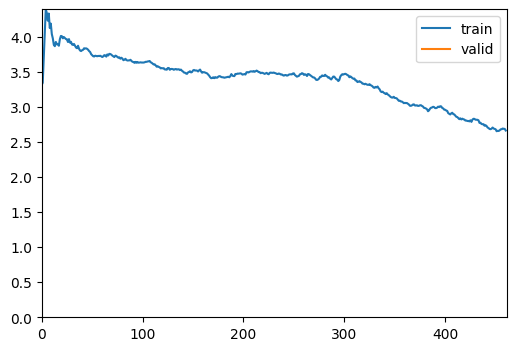

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.361575,2.206147,0.046549,0.425535,0.572668,00:55
1,2.150021,2.223758,0.063427,0.503378,0.577007,00:52
2,2.235711,2.043224,0.044974,0.297820,0.633406,00:54
3,2.172202,2.243716,0.045738,0.323562,0.420824,00:50
4,2.199793,2.036877,0.037863,0.475034,0.626898,00:53
5,2.219524,2.070276,0.042129,0.484041,0.613883,00:52


Better model found at epoch 0 with valid_loss value: 2.2061471939086914.


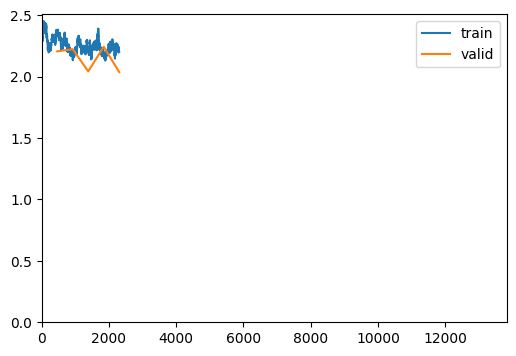

Better model found at epoch 2 with valid_loss value: 2.0432240962982178.
Better model found at epoch 4 with valid_loss value: 2.036876678466797.
No improvement since epoch 1: early stopping


In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_cancer', comp=np.greater, patience=4),
    SaveModelCallback(fname='Resnet50')
]

model = MultiTaskModel(resnet50(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=callbacks, metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

### EfficientNet

In [ ]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1536,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1536,2,ps=ps)
        self.fc3 = create_head(1536,11,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.818462,11.124595,0.076171,0.139035,0.470716,01:17


Better model found at epoch 0 with valid_loss value: 11.124594688415527.


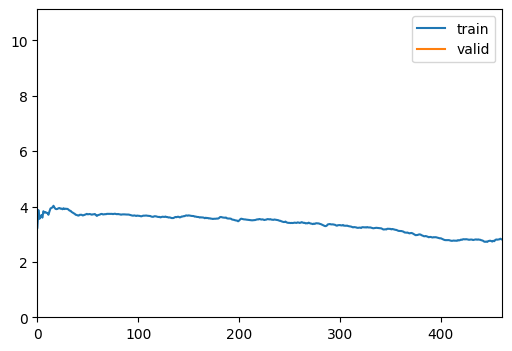

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.221030,2.368971,0.056291,0.553352,0.583514,01:16
1,2.286291,2.217839,0.058961,0.535151,0.568330,01:17
2,2.298868,2.140873,0.046513,0.161388,0.587852,01:15
3,2.228118,2.349787,0.070928,0.256668,0.581345,01:17
4,2.307042,3.145257,0.055126,0.645842,0.546638,01:15
5,2.286758,2.118063,0.039312,0.114534,0.587852,01:17
6,2.292382,2.150012,0.040676,0.327673,0.596529,01:17
7,2.230079,2.419433,0.051664,0.152422,0.503254,01:15
8,2.292593,2.331614,0.047369,0.519450,0.568330,01:17


Better model found at epoch 0 with valid_loss value: 2.368971109390259.


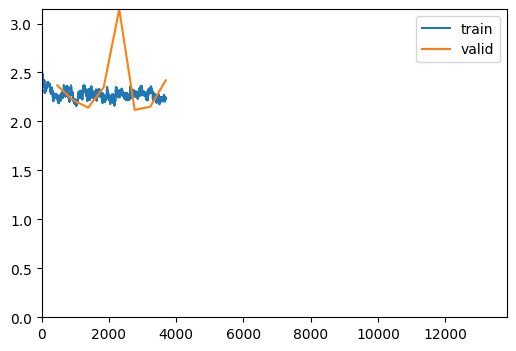

Better model found at epoch 1 with valid_loss value: 2.217839479446411.
Better model found at epoch 2 with valid_loss value: 2.1408731937408447.
Better model found at epoch 5 with valid_loss value: 2.11806321144104.
No improvement since epoch 4: early stopping


In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_cancer', comp=np.greater, patience=4),
    SaveModelCallback(fname='Efficientnet')
]

model = MultiTaskModel(efficientnet_b3(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=callbacks, metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

### ConvNext

In [ ]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1024,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1024,2,ps=ps)
        self.fc3 = create_head(1024,11,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.860992,2.375263,0.049843,0.488214,0.581345,02:28


Better model found at epoch 0 with valid_loss value: 2.3752634525299072.


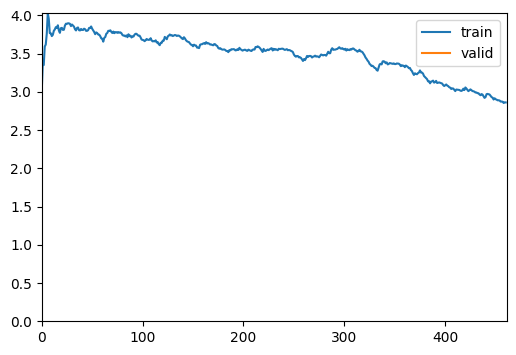

epoch,train_loss,valid_loss,rmse_age,f1_cancer,acc_density,time
0,2.218265,2.189574,0.044621,0.511497,0.581345,02:28
1,2.233337,2.121881,0.040529,0.526805,0.579176,02:28
2,2.176676,2.111870,0.042187,0.505278,0.635575,02:28
3,2.203695,2.086492,0.038035,0.559632,0.598698,02:27
4,2.259533,2.043930,0.040386,0.364590,0.672451,02:28
5,2.259569,2.239277,0.039790,0.586138,0.594360,02:29
6,2.233399,2.274268,0.044886,0.422725,0.412147,02:29
7,2.191365,2.086821,0.039772,0.486313,0.585683,02:29
8,2.238799,2.256265,0.038486,0.582502,0.492408,02:29
9,2.141832,2.167290,0.035421,0.105857,0.624729,02:29


Better model found at epoch 0 with valid_loss value: 2.1895740032196045.


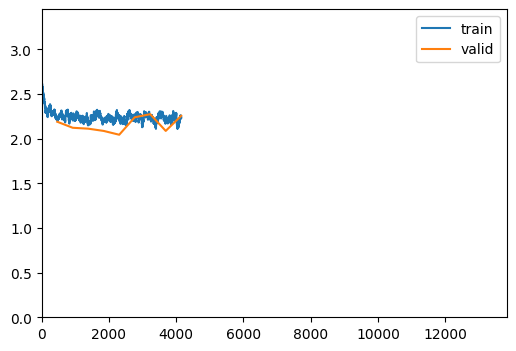

Better model found at epoch 1 with valid_loss value: 2.1218810081481934.
Better model found at epoch 2 with valid_loss value: 2.1118698120117188.
Better model found at epoch 3 with valid_loss value: 2.0864920616149902.
Better model found at epoch 4 with valid_loss value: 2.0439295768737793.
No improvement since epoch 5: early stopping


In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_cancer', comp=np.greater, patience=4),
    SaveModelCallback(fname='ConvNext')
]

model = MultiTaskModel(convnext_base(), ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=callbacks, metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

### HRNet

In [ ]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1024,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1024,2,ps=ps)
        self.fc3 = create_head(1024,11,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

In [ ]:
from timm import create_model
from fastai.vision.learner import _update_first_layer

def create_timm_body(arch:str, pretrained=True, cut=None, n_in=3):
    "Creates a body from any model in the `timm` library."
    model = create_model(arch, pretrained=pretrained, num_classes=0, global_pool='')
    _update_first_layer(model, n_in, pretrained)
    if cut is None:
        ll = list(enumerate(model.children()))
        cut = next(i for i,o in reversed(ll) if has_pool_type(o))
    if isinstance(cut, int): return nn.Sequential(*list(model.children())[:cut])
    elif callable(cut): return cut(model)
    else: print("cut must be either integer or function")

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_cancer', comp=np.greater, patience=4),
    SaveModelCallback(fname='Hrnet')
]

body = create_timm_body('hrnet_w44', pretrained=True)
nf = num_features_model(body)
head = create_head(nf, data.c, concat_pool=True)
net = nn.Sequential(body, head)

model = MultiTaskModel(net, ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=callbacks, metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

NotImplementedError: ignored

### Deit

In [ ]:
class MultiTaskModel(nn.Module):
    """
    Creates a MTL model with the encoder from "arch" and with dropout multiplier ps.
    """
    def __init__(self, arch, ps=0.5):
        super(MultiTaskModel, self).__init__()
        self.encoder = create_body(arch)        #fastai function that creates an encoder given an architecture
        self.fc1 = create_head(1024,1,ps=ps)    #fastai function that creates a head
        self.fc2 = create_head(1024,2,ps=ps)
        self.fc3 = create_head(1024,11,ps=ps)

    def forward(self, x):

        x = self.encoder(x)
        age = torch.sigmoid(self.fc1(x))
        cancer = self.fc2(x)
        density = self.fc3(x)

        return [age, cancer, density]

In [ ]:
callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_cancer', comp=np.greater, patience=4),
    SaveModelCallback(fname='Deit')
]

body = create_timm_body('deit3_base_patch16_384', pretrained=True)
nf = num_features_model(body)
head = create_head(nf, data.c, concat_pool=True)
net = nn.Sequential(body, head)

model = MultiTaskModel(net, ps=0.25)
learn = Learner(data, model, loss_func=loss_func, cbs=callbacks, metrics=metrics)
learn.fine_tune(30, base_lr=1e-3)

## Procesamiento de datos

In [ ]:
dfb2

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case,label
63,2,10106,190315990,R,MLO,57,0,0,0,0,0,1,21,0,57 0 1
87,1,10130,388811999,L,MLO,71,1,1,1,0,0,1,49,0,71 1 1
88,1,10130,613462606,L,CC,71,1,1,1,0,0,1,49,0,71 1 1
89,1,10130,1360338805,L,CC,71,1,1,1,0,0,1,49,0,71 1 1
90,1,10130,1672636630,L,MLO,71,1,1,1,0,0,1,49,0,71 1 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54596,2,9851,1434430689,L,CC,58,1,1,0,0,0,1,48,0,58 1 1
54599,2,9852,948754725,L,CC,58,0,0,0,0,0,1,29,0,58 0 1
54627,1,9894,1991772614,R,CC,50,0,1,0,0,0,1,49,1,50 0 1
54636,2,990,837618473,R,MLO,57,0,0,0,1,0,1,48,0,57 0 1


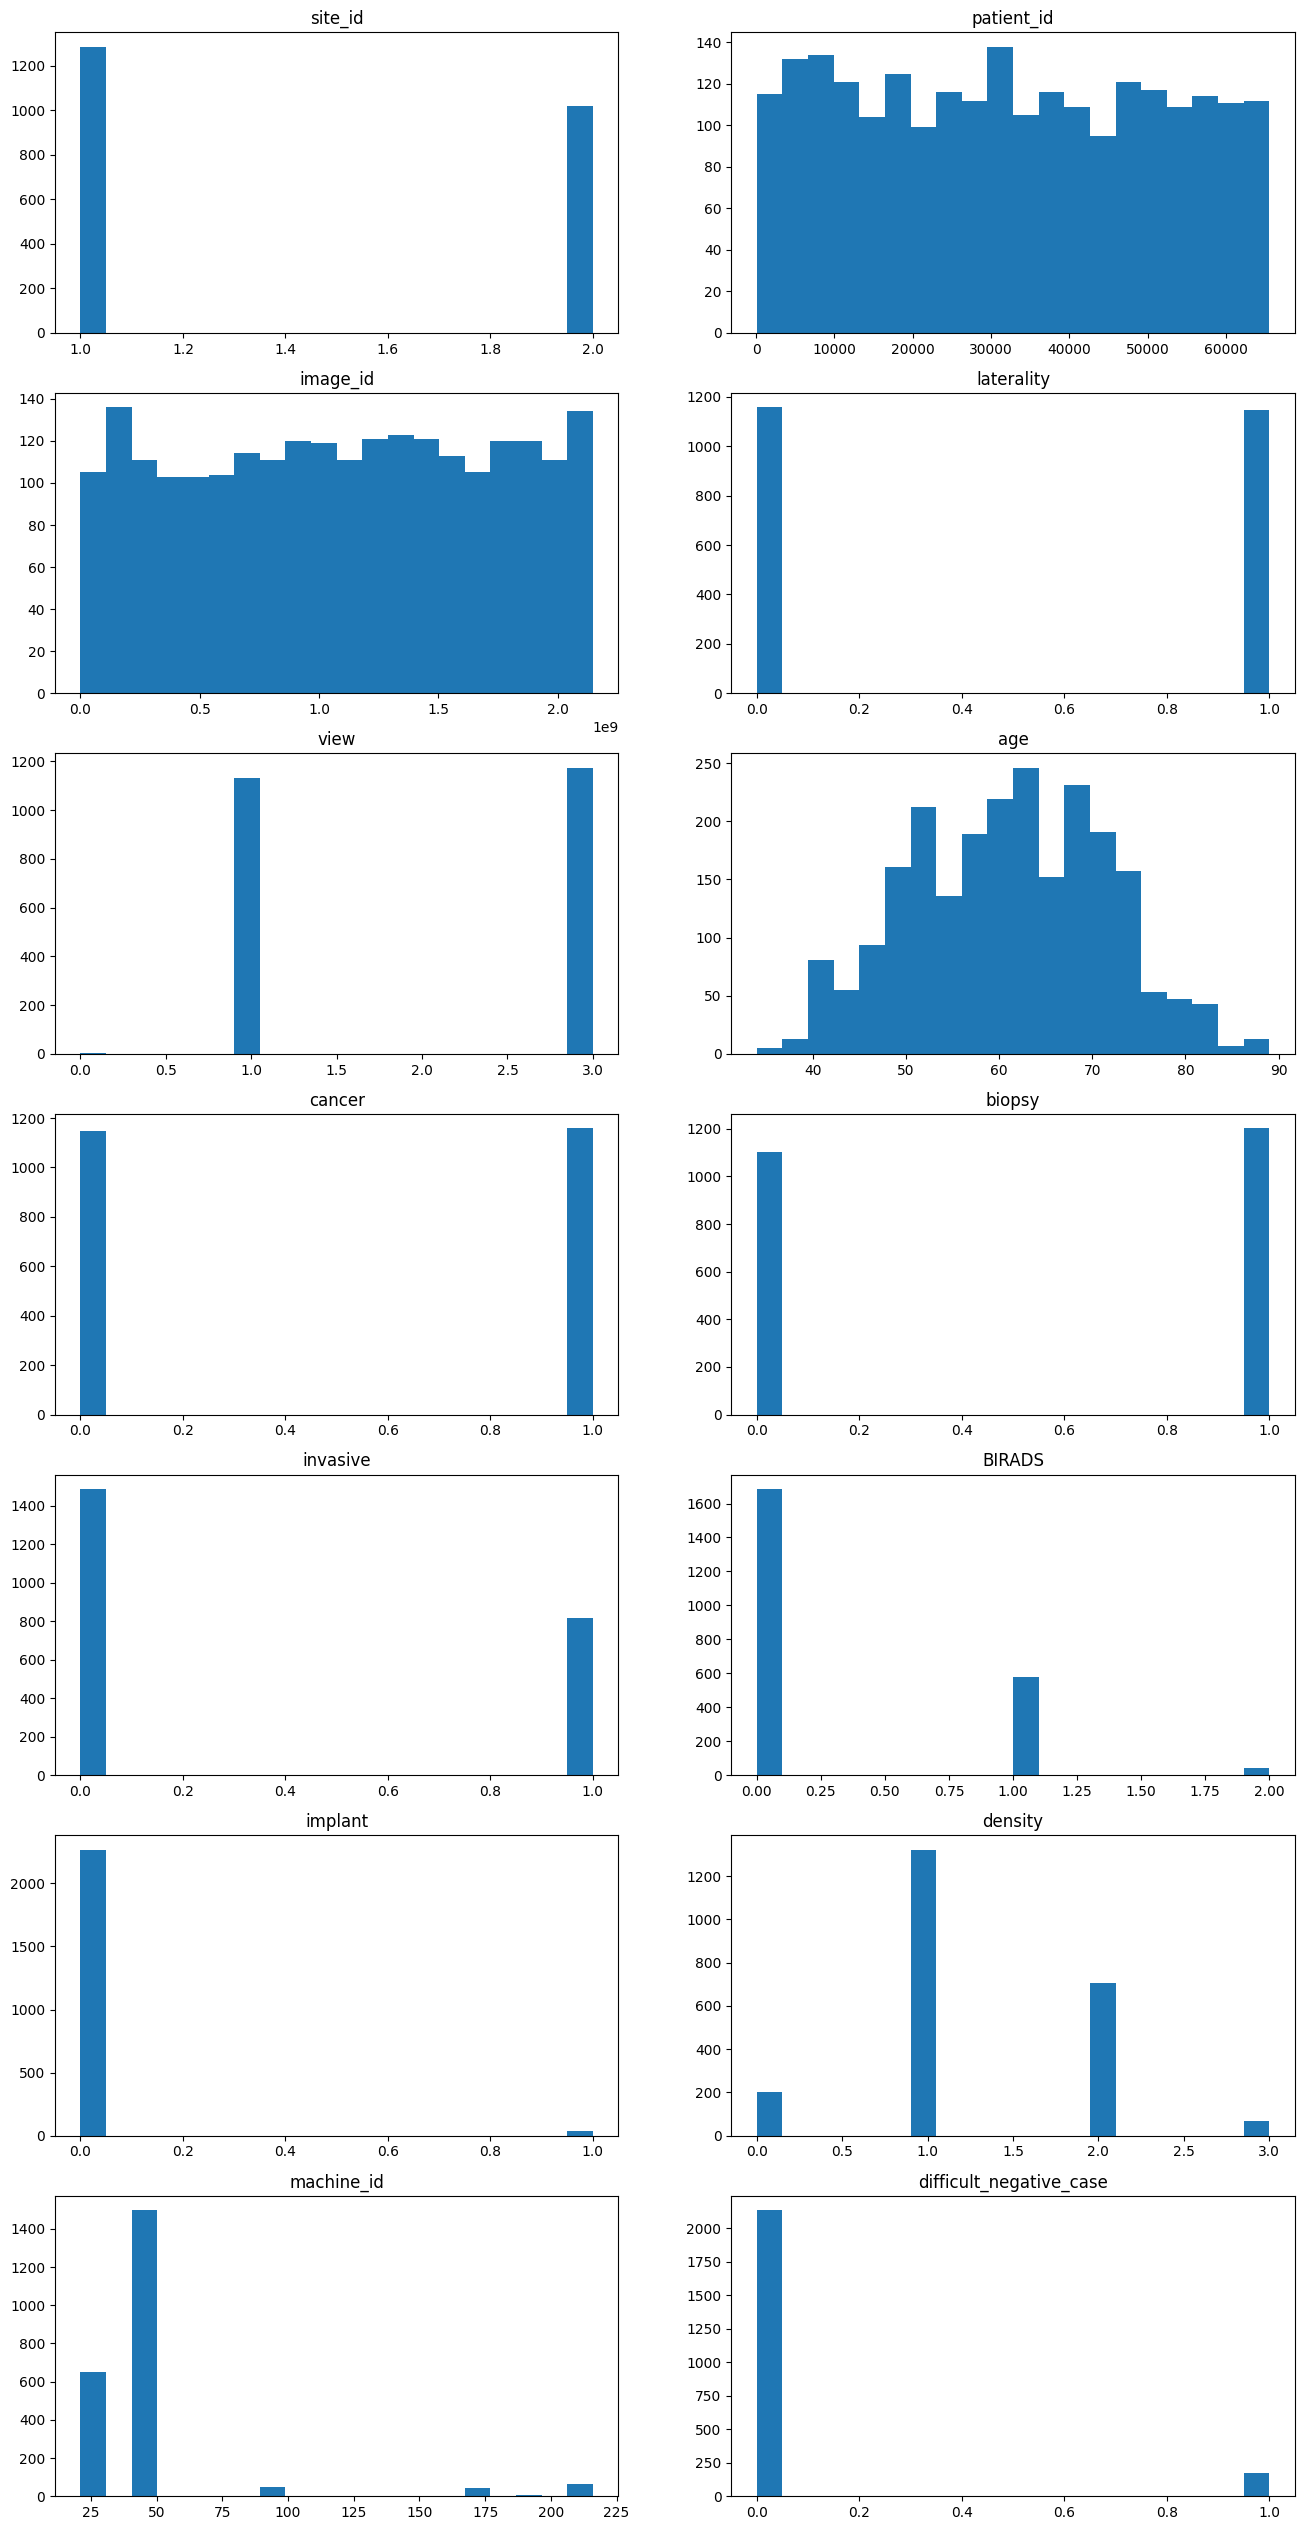

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
dfb2[["laterality","view"]] = enc.fit_transform(dfb2[["laterality","view"]])
fig, axes = plt.subplots(7, 2, figsize = (16, 32))
axes[0,0].hist(dfb2["site_id"].values, bins = 20)
axes[0,0].set_title("site_id")
axes[0,1].hist(dfb2["patient_id"].values, bins = 20)
axes[0,1].set_title("patient_id")
axes[1,0].hist(dfb2["image_id"].values, bins = 20)
axes[1,0].set_title("image_id")
axes[1,1].hist(dfb2["laterality"].values, bins = 20)
axes[1,1].set_title("laterality")
axes[2,0].hist(dfb2["view"].values, bins = 20)
axes[2,0].set_title("view")
axes[2,1].hist(dfb2["age"].values, bins = 20)
axes[2,1].set_title("age")
axes[3,0].hist(dfb2["cancer"].values, bins = 20)
axes[3,0].set_title("cancer")
axes[3,1].hist(dfb2["biopsy"].values, bins = 20)
axes[3,1].set_title("biopsy")
axes[4,0].hist(dfb2["invasive"].values, bins = 20)
axes[4,0].set_title("invasive")
axes[4,1].hist(dfb2["BIRADS"].values, bins = 20)
axes[4,1].set_title("BIRADS")
axes[5,0].hist(dfb2["implant"].values, bins = 20)
axes[5,0].set_title("implant")
axes[5,1].hist(dfb2["density"].values, bins = 20)
axes[5,1].set_title("density")
axes[6,0].hist(dfb2["machine_id"].values, bins = 20)
axes[6,0].set_title("machine_id")
axes[6,1].hist(dfb2["difficult_negative_case"].values, bins = 20)
axes[6,1].set_title("difficult_negative_case")
plt.show()

In [ ]:
from sklearn import preprocessing, model_selection, metrics

np.random.seed(0)

train_ratio = 0.7
validation_ratio = 0.1
test_ratio = 0.2

X = dfb2.loc[::, ["age", "density"]].copy()
y = dfb2.loc[::, "cancer"].copy()

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size = 1 - train_ratio)
X_val, X_test, y_val, y_test = model_selection.train_test_split(X_test, y_test, test_size = test_ratio / (test_ratio + validation_ratio))

normalizar = preprocessing.StandardScaler()
X_train_norm = normalizar.fit_transform(X_train)
X_val_norm = normalizar.fit_transform(X_val)
X_test_norm = normalizar.fit_transform(X_test)

### Modelos

In [ ]:
from sklearn.linear_model import SGDRegressor, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn import metrics

#### Árbol C4.5

In [ ]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_val), y_val) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': None, 'min_samples_split': 2}, 72.78, 70.43)

#### Árbol CART

In [ ]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_val), y_val) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': None, 'min_samples_split': 2}, 72.78, 70.43)

#### Regresión Logística

In [ ]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_val), y_val) * 100, 2)
mejorConfiguracion3, accTrain, accTest

({'C': 0.01}, 62.18, 63.04)

#### Red Neuronal

In [ ]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_val), y_val) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.1, 'hidden_layer_sizes': 50}, 53.32, 52.17)

#### SVM

In [ ]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_val), y_val) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 69.81, 70.87)

#### Random Forest

In [ ]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_val), y_val) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'entropy', 'max_features': None},
 72.78,
 70.43)

#### Resultados

In [ ]:
def mostrar_resultados(nombre, modelo, X_val, y_val):
    print('> ', nombre)

    prediccion = modelo.predict(X_val)
    score = round(modelo.score(X_val, y_val) * 100, 2)
    print('>  Accuracy: {}\n'.format(score))

    matriz = metrics.confusion_matrix(y_val, prediccion)
    print(matriz)
    plt.rcParams["figure.figsize"] = (8, 6)
    print(metrics.classification_report(y_val, prediccion, zero_division=0))

In [ ]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_val, y_val)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_val, y_val)
mostrar_resultados("Regresión logística", clasificadores3, X_val, y_val)
mostrar_resultados("Red neuronal", clasificadores4, X_val, y_val)
mostrar_resultados("SVM", clasificadores5, X_val, y_val)
mostrar_resultados("Random Forest", clasificadores6, X_val, y_val)

>  Árbol de Decisión C4.5
>  Accuracy: 70.43

[[84 32]
 [36 78]]
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       116
           1       0.71      0.68      0.70       114

    accuracy                           0.70       230
   macro avg       0.70      0.70      0.70       230
weighted avg       0.70      0.70      0.70       230

>  Árbol de Decisión CART
>  Accuracy: 70.43

[[84 32]
 [36 78]]
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       116
           1       0.71      0.68      0.70       114

    accuracy                           0.70       230
   macro avg       0.70      0.70      0.70       230
weighted avg       0.70      0.70      0.70       230

>  Regresión logística
>  Accuracy: 63.04

[[64 52]
 [33 81]]
              precision    recall  f1-score   support

           0       0.66      0.55      0.60       116
           1       0.61      0.71      0.66  

### Modelos Normalizado

#### Árbol C4.5

In [ ]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': None, 'min_samples_split': 2}, 100.0, 58.26)

#### Árbol CART

In [ ]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': None, 'min_samples_split': 2}, 100.0, 63.04)

#### Regresión Logística

In [ ]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion3, accTrain, accTest

({'C': 1}, 62.86, 60.43)

#### Red Neuronal

In [ ]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.001, 'hidden_layer_sizes': 50}, 68.63, 63.04)

#### SVM

In [ ]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 69.06, 63.04)

#### Random Forest

In [ ]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train_norm, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train_norm), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_val_norm), y_val) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': False, 'criterion': 'gini', 'max_features': 'sqrt'},
 100.0,
 66.96)

#### Resultados

In [ ]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_val_norm, y_val)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_val_norm, y_val)
mostrar_resultados("Regresión logística", clasificadores3, X_val_norm, y_val)
mostrar_resultados("Red neuronal", clasificadores4, X_val_norm, y_val)
mostrar_resultados("SVM", clasificadores5, X_val_norm, y_val)
mostrar_resultados("Random Forest", clasificadores6, X_val_norm, y_val)

>  Árbol de Decisión C4.5
>  Accuracy: 58.26

[[69 47]
 [49 65]]
              precision    recall  f1-score   support

           0       0.58      0.59      0.59       116
           1       0.58      0.57      0.58       114

    accuracy                           0.58       230
   macro avg       0.58      0.58      0.58       230
weighted avg       0.58      0.58      0.58       230

>  Árbol de Decisión CART
>  Accuracy: 63.04

[[74 42]
 [43 71]]
              precision    recall  f1-score   support

           0       0.63      0.64      0.64       116
           1       0.63      0.62      0.63       114

    accuracy                           0.63       230
   macro avg       0.63      0.63      0.63       230
weighted avg       0.63      0.63      0.63       230

>  Regresión logística
>  Accuracy: 60.43

[[63 53]
 [38 76]]
              precision    recall  f1-score   support

           0       0.62      0.54      0.58       116
           1       0.59      0.67      0.63  

### Conjunto de Test

In [ ]:
X_train = pd.concat([X_train, X_val], ignore_index = True)
y_train = pd.concat([y_train, y_val], ignore_index = True)

In [ ]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0, max_depth = None, min_samples_split = 2)
arbolC45.fit(X_train, y_train.values.ravel())
mostrar_resultados("arbol C4.5", arbolC45, X_test, y_test)

>  arbol C4.5
>  Accuracy: 70.56

[[166  67]
 [ 69 160]]
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       233
           1       0.70      0.70      0.70       229

    accuracy                           0.71       462
   macro avg       0.71      0.71      0.71       462
weighted avg       0.71      0.71      0.71       462



In [ ]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0, max_depth = None, min_samples_split = 2)
arbolCART.fit(X_train, y_train.values.ravel())
mostrar_resultados("arbol CART", arbolCART, X_test, y_test)

>  arbol CART
>  Accuracy: 70.56

[[166  67]
 [ 69 160]]
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       233
           1       0.70      0.70      0.70       229

    accuracy                           0.71       462
   macro avg       0.71      0.71      0.71       462
weighted avg       0.71      0.71      0.71       462



In [ ]:
rf = RandomForestClassifier(random_state = 0, bootstrap = True, criterion = 'entropy', max_features = None)
rf.fit(X_train, y_train.values.ravel())
mostrar_resultados("Random Forest", rf, X_test, y_test)

>  Random Forest
>  Accuracy: 72.08

[[167  66]
 [ 63 166]]
              precision    recall  f1-score   support

           0       0.73      0.72      0.72       233
           1       0.72      0.72      0.72       229

    accuracy                           0.72       462
   macro avg       0.72      0.72      0.72       462
weighted avg       0.72      0.72      0.72       462



In [ ]:
rl = LogisticRegression(C=0.01)
rl.fit(X_train, y_train.values.ravel())
mostrar_resultados("Regresión Logística", rl, X_test, y_test)

>  Regresión Logística
>  Accuracy: 64.29

[[141  92]
 [ 73 156]]
              precision    recall  f1-score   support

           0       0.66      0.61      0.63       233
           1       0.63      0.68      0.65       229

    accuracy                           0.64       462
   macro avg       0.64      0.64      0.64       462
weighted avg       0.64      0.64      0.64       462



In [ ]:
rn = MLPClassifier(random_state = 0 , alpha = 0.1, hidden_layer_sizes = 50)
rn.fit(X_train, y_train.values.ravel())
mostrar_resultados("Red Neuronal", rn, X_test, y_test)

>  Red Neuronal
>  Accuracy: 62.55

[[ 92 141]
 [ 32 197]]
              precision    recall  f1-score   support

           0       0.74      0.39      0.52       233
           1       0.58      0.86      0.69       229

    accuracy                           0.63       462
   macro avg       0.66      0.63      0.61       462
weighted avg       0.66      0.63      0.60       462



In [ ]:
SVM = SVC(gamma = "auto", random_state = 0, decision_function_shape = 'ovo')
SVM.fit(X_train, y_train.values.ravel())
mostrar_resultados("SVM", SVM, X_test, y_test)

>  SVM
>  Accuracy: 69.26

[[153  80]
 [ 62 167]]
              precision    recall  f1-score   support

           0       0.71      0.66      0.68       233
           1       0.68      0.73      0.70       229

    accuracy                           0.69       462
   macro avg       0.69      0.69      0.69       462
weighted avg       0.69      0.69      0.69       462



### Recorte de dataset

In [ ]:
from itertools import chain, combinations
def powerset(list_name):
    s = list(list_name)
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))

In [ ]:
combinaciones = powerset(X_train.columns[3:8])
for comb in combinaciones:
    comb = list(comb)
    if comb != []:
        rf = RandomForestClassifier(random_state = 0, bootstrap = False, criterion = 'gini', max_features = 'sqrt')
        rf.fit(X_train.loc[:, comb] , y_train.values.ravel())
        mostrar_resultados("Random Forest " + str(comb), rf, X_test.loc[:, comb], y_test)

>  Random Forest ['laterality']
>  Accuracy: 48.05

[[113 120]
 [120 109]]
              precision    recall  f1-score   support

           0       0.48      0.48      0.48       233
           1       0.48      0.48      0.48       229

    accuracy                           0.48       462
   macro avg       0.48      0.48      0.48       462
weighted avg       0.48      0.48      0.48       462

>  Random Forest ['view']
>  Accuracy: 49.57

[[  0 233]
 [  0 229]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       233
           1       0.50      1.00      0.66       229

    accuracy                           0.50       462
   macro avg       0.25      0.50      0.33       462
weighted avg       0.25      0.50      0.33       462

>  Random Forest ['age']
>  Accuracy: 61.47

[[142  91]
 [ 87 142]]
              precision    recall  f1-score   support

           0       0.62      0.61      0.61       233
           1       0.61  

In [ ]:
def latexiza(comb):
    l = ""
    for i in comb:
        j = i
        if '_' in i:
            j = i.replace("_", "\_")
        l = l + "`" + j + "'"
        if i != comb[-1]:
            l = l + ", "
    return l

def numera(n):
    n = str(n)
    n = n.replace(".", ",")
    return n[:6]

def mostrar_resultados2(comb, modelo, X_val, y_val):
    prediccion = modelo.predict(X_val)
    score = numera(round(modelo.score(X_val, y_val) * 100, 2) / 100)
    matriz = metrics.confusion_matrix(y_val, prediccion)
    cr = metrics.classification_report(y_val, prediccion, zero_division=0)
    fn = numera(cr[94:98])
    fp = numera(cr[148:152])
    comb = latexiza(comb)
    print("\hline")
    print("\multicolumn{1}{|m{6cm}|}{" + comb + "} & " + score + " & " + fn + " & " + fp + " \\\\")

In [ ]:
X_train_norm = pd.DataFrame(data = X_train_norm,
                  columns = X_train.columns)

X_test_norm = pd.DataFrame(data = X_test_norm,
                  columns = X_test.columns)

In [ ]:
combinaciones = powerset(X_train_norm.columns)
for comb in combinaciones:
    comb = list(comb)
    if comb != []:
        dt = DecisionTreeClassifier(criterion = 'entropy', random_state = 0, max_depth = 10, min_samples_split= 20)
        dt.fit(X_train_norm.loc[:, comb] , y_train.values.ravel())
        mostrar_resultados2(comb, dt, X_test_norm.loc[:, comb], y_test)

\hline
\multicolumn{1}{|m{6cm}|}{`laterality'} & 0,4805 & 0,48 & 0,48 \\
\hline
\multicolumn{1}{|m{6cm}|}{`view'} & 0,4957 & 0,00 & 0,66 \\
\hline
\multicolumn{1}{|m{6cm}|}{`age'} & 0,5779 & 0,60 & 0,56 \\
\hline
\multicolumn{1}{|m{6cm}|}{`implant'} & 0,5043 & 0,05 & 0,66 \\
\hline
\multicolumn{1}{|m{6cm}|}{`density'} & 0,5195 & 0,24 & 0,65 \\
\hline
\multicolumn{1}{|m{6cm}|}{`laterality', `view'} & 0,4675 & 0,28 & 0,58 \\
\hline
\multicolumn{1}{|m{6cm}|}{`laterality', `age'} & 0,5736 & 0,59 & 0,56 \\
\hline
\multicolumn{1}{|m{6cm}|}{`laterality', `implant'} & 0,4847 & 0,49 & 0,48 \\
\hline
\multicolumn{1}{|m{6cm}|}{`laterality', `density'} & 0,513 & 0,47 & 0,55 \\
\hline
\multicolumn{1}{|m{6cm}|}{`view', `age'} & 0,5736 & 0,60 & 0,55 \\
\hline
\multicolumn{1}{|m{6cm}|}{`view', `implant'} & 0,5022 & 0,03 & 0,67 \\
\hline
\multicolumn{1}{|m{6cm}|}{`view', `density'} & 0,4957 & 0,34 & 0,59 \\
\hline
\multicolumn{1}{|m{6cm}|}{`age', `implant'} & 0,5822 & 0,61 & 0,55 \\
\hline
\multicolumn

## Aprox 2

In [30]:
from sklearn.linear_model import SGDRegressor, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn import model_selection, metrics

In [31]:
def creaDF(separacion, caracteristicas, df):
    dfb = df[['age', 'cancer', 'density']].copy()
    lista = []
    for i in range(len(caracteristicas)):
        img = separacion[i]
        serie = dfb.iloc[img]
        car = caracteristicas[i].cpu().numpy()
        for j in range(len(car)):
            serie = pd.concat([serie, pd.Series({j: car[j]})])
        lista.append(serie)
    return pd.DataFrame(lista)

def mostrar_resultados(nombre, modelo, X_val, y_val):
    print('> ', nombre)

    prediccion = modelo.predict(X_val)
    score = round(modelo.score(X_val, y_val) * 100, 2)
    print('>  Accuracy: {}\n'.format(score))

    matriz = metrics.confusion_matrix(y_val, prediccion)
    print(matriz)
    plt.rcParams["figure.figsize"] = (8, 6)
    print(metrics.classification_report(y_val, prediccion, zero_division=0))

### Resnet50

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 105MB/s]


epoch,train_loss,valid_loss,f1_score,time
0,1.333403,1.279865,0.608997,00:37


Better model found at epoch 0 with valid_loss value: 1.2798645496368408.


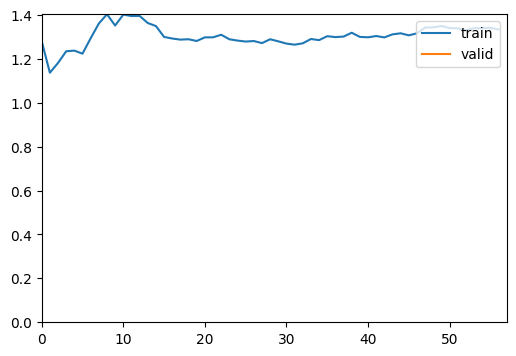

epoch,train_loss,valid_loss,f1_score,time
0,1.099799,1.254499,0.603066,00:42
1,1.008068,0.946032,0.602637,00:42
2,0.997570,0.830497,0.555789,00:44
3,0.993327,0.953297,0.497758,00:44
4,0.950148,0.889797,0.553846,00:42


Better model found at epoch 0 with valid_loss value: 1.2544994354248047.


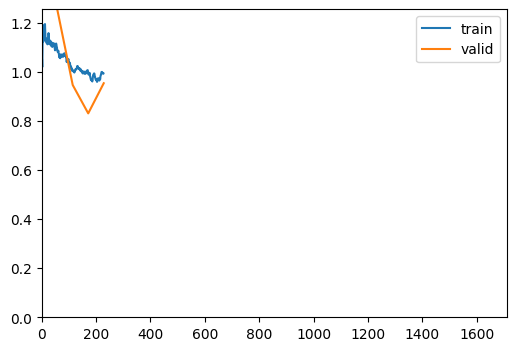

Better model found at epoch 1 with valid_loss value: 0.9460321068763733.
Better model found at epoch 2 with valid_loss value: 0.8304969668388367.
No improvement since epoch 0: early stopping


In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

dls = db.dataloaders(p_under2, bs=32)

callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=4),
    SaveModelCallback(fname='modelResnet50')
]

learn = vision_learner(dls, resnet50, metrics=F1Score(), cbs=callbacks).to_fp16()
learn.fine_tune(30, base_lr=1e-3)

In [ ]:
learn.model[1] = learn.model[1][:-4]

caracteristicas_train = []
with torch.no_grad():
    for images, labels in dls[0]:
        outputs = learn.model(images)
        caracteristicas_train.extend(outputs)

caracteristicas_test = []
with torch.no_grad():
    for images, labels in dls[1]:
        outputs = learn.model(images)
        caracteristicas_test.extend(outputs)

img_train, img_test = db.splitter(db.get_items(p_under2))

In [ ]:
dftrain = creaDF(img_train, caracteristicas_train, dfb2)
dftrain.columns = dftrain.columns.astype(str)
dftest = creaDF(img_test, caracteristicas_test, dfb2)
dftest.columns = dftest.columns.astype(str)

X_train = dftrain.drop(["cancer"], axis=1).copy()
y_train = dftrain.loc[::, "cancer"].copy()

X_test = dftest.drop(["cancer"], axis=1).copy()
y_test = dftest.loc[::, "cancer"].copy()

#### Segundo paso

In [ ]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_test), y_test) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 20}, 68.48, 63.34)

In [ ]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_test), y_test) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 68.86, 60.52)

In [ ]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_test), y_test) * 100, 2)
mejorConfiguracion3, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

({'C': 0.001}, 68.86, 60.52)

In [ ]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_test), y_test) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.01, 'hidden_layer_sizes': 10}, 99.73, 46.64)

In [ ]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_test), y_test) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 100.0, 59.0)

In [ ]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_test), y_test) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'entropy', 'max_features': None},
 100.0,
 59.65)

In [ ]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_test, y_test)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_test, y_test)
mostrar_resultados("Regresión logística", clasificadores3, X_test, y_test)
mostrar_resultados("Red neuronal", clasificadores4, X_test, y_test)
mostrar_resultados("SVM", clasificadores5, X_test, y_test)
mostrar_resultados("Random Forest", clasificadores6, X_test, y_test)

>  Árbol de Decisión C4.5
>  Accuracy: 63.34

[[149  85]
 [ 84 143]]
              precision    recall  f1-score   support

         0.0       0.64      0.64      0.64       234
         1.0       0.63      0.63      0.63       227

    accuracy                           0.63       461
   macro avg       0.63      0.63      0.63       461
weighted avg       0.63      0.63      0.63       461

>  Árbol de Decisión CART
>  Accuracy: 60.52

[[125 109]
 [ 73 154]]
              precision    recall  f1-score   support

         0.0       0.63      0.53      0.58       234
         1.0       0.59      0.68      0.63       227

    accuracy                           0.61       461
   macro avg       0.61      0.61      0.60       461
weighted avg       0.61      0.61      0.60       461

>  Regresión logística
>  Accuracy: 60.52

[[117 117]
 [ 65 162]]
              precision    recall  f1-score   support

         0.0       0.64      0.50      0.56       234
         1.0       0.58      0.71

### EfficientNet

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


epoch,train_loss,valid_loss,f1_score,time
0,1.325394,nan,0.154982,00:57


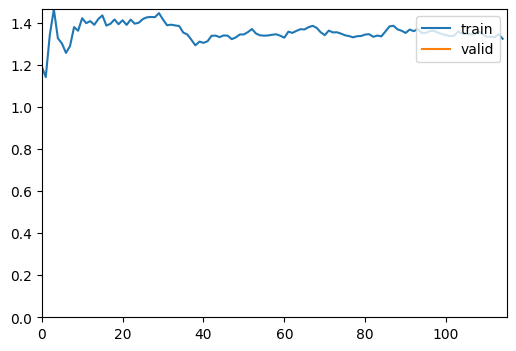

FileNotFoundError: ignored

In [ ]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

dls = db.dataloaders(p_under2, bs=16)

callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=4),
    SaveModelCallback(fname='efficientNetB3')
]

learn = vision_learner(dls, efficientnet_b3, metrics=F1Score(), cbs=callbacks).to_fp16()
learn.fine_tune(30, base_lr=1e-3)

In [ ]:
learn.model[1] = learn.model[1][:-4]

caracteristicas_train = []
with torch.no_grad():
    for images, labels in dls[0]:
        outputs = learn.model(images)
        caracteristicas_train.extend(outputs)

caracteristicas_test = []
with torch.no_grad():
    for images, labels in dls[1]:
        outputs = learn.model(images)
        caracteristicas_test.extend(outputs)

img_train, img_test = db.splitter(db.get_items(p_under2))

In [ ]:
dftrain = creaDF(img_train, caracteristicas_train, dfb2)
dftrain.columns = dftrain.columns.astype(str)
dftest = creaDF(img_test, caracteristicas_test, dfb2)
dftest.columns = dftest.columns.astype(str)

X_train = dftrain.drop(["cancer"], axis=1).copy()
y_train = dftrain.loc[::, "cancer"].copy()

X_test = dftest.drop(["cancer"], axis=1).copy()
y_test = dftest.loc[::, "cancer"].copy()

#### Segundo paso

In [ ]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_test), y_test) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 67.39, 61.61)

In [ ]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_test), y_test) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 72.61, 47.94)

In [ ]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_test), y_test) * 100, 2)
mejorConfiguracion3, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

({'C': 0.001}, 71.2, 49.46)

In [ ]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_test), y_test) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.1, 'hidden_layer_sizes': 10}, 100.0, 51.19)

In [ ]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_test), y_test) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 100.0, 50.33)

In [ ]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_test), y_test) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'gini', 'max_features': None}, 100.0, 44.9)

In [ ]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_test, y_test)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_test, y_test)
mostrar_resultados("Regresión logística", clasificadores3, X_test, y_test)
mostrar_resultados("Red neuronal", clasificadores4, X_test, y_test)
mostrar_resultados("SVM", clasificadores5, X_test, y_test)
mostrar_resultados("Random Forest", clasificadores6, X_test, y_test)

>  Árbol de Decisión C4.5
>  Accuracy: 61.61

[[147  87]
 [ 90 137]]
              precision    recall  f1-score   support

         0.0       0.62      0.63      0.62       234
         1.0       0.61      0.60      0.61       227

    accuracy                           0.62       461
   macro avg       0.62      0.62      0.62       461
weighted avg       0.62      0.62      0.62       461

>  Árbol de Decisión CART
>  Accuracy: 47.94

[[134 100]
 [140  87]]
              precision    recall  f1-score   support

         0.0       0.49      0.57      0.53       234
         1.0       0.47      0.38      0.42       227

    accuracy                           0.48       461
   macro avg       0.48      0.48      0.47       461
weighted avg       0.48      0.48      0.47       461

>  Regresión logística
>  Accuracy: 49.46

[[ 87 147]
 [ 86 141]]
              precision    recall  f1-score   support

         0.0       0.50      0.37      0.43       234
         1.0       0.49      0.62

### ConvNext

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth
100%|██████████| 338M/338M [00:06<00:00, 55.1MB/s]


epoch,train_loss,valid_loss,f1_score,time
0,1.298146,1.298936,0.653251,01:43


Better model found at epoch 0 with valid_loss value: 1.2989362478256226.


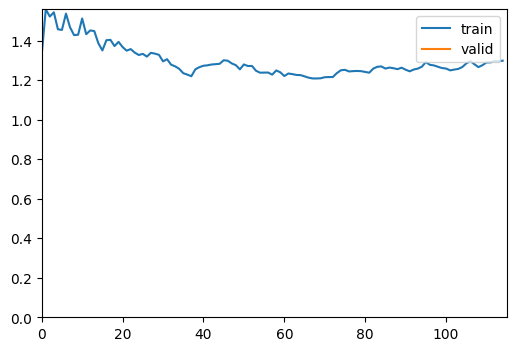

epoch,train_loss,valid_loss,f1_score,time
0,1.065354,0.828473,0.615679,02:04
1,1.025189,0.803203,0.582645,02:04
2,1.001678,0.783357,0.575693,02:05
3,0.980493,0.826625,0.656195,02:05
4,0.975490,0.809291,0.583162,02:05
5,0.914248,0.748107,0.607966,02:05
6,0.866629,0.751192,0.558442,02:04


Better model found at epoch 0 with valid_loss value: 0.828472912311554.


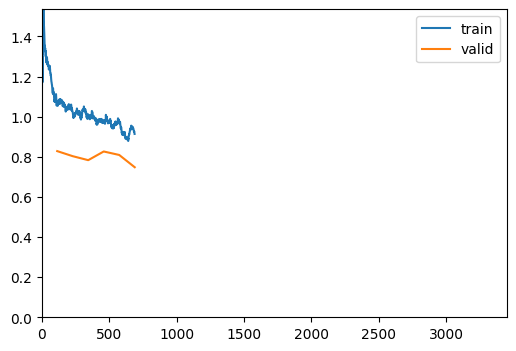

Better model found at epoch 1 with valid_loss value: 0.8032034039497375.
Better model found at epoch 2 with valid_loss value: 0.7833565473556519.
Better model found at epoch 5 with valid_loss value: 0.7481065392494202.
No improvement since epoch 3: early stopping


In [32]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

dls = db.dataloaders(p_under2, bs=16)

callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='ConvNext')
]

learn = vision_learner(dls, convnext_base, metrics=F1Score(), cbs=callbacks).to_fp16()
learn.fine_tune(30, base_lr=1e-3)

In [33]:
learn.model[1] = learn.model[1][:-4]

caracteristicas_train = []
with torch.no_grad():
    for images, labels in dls[0]:
        outputs = learn.model(images)
        caracteristicas_train.extend(outputs)

caracteristicas_test = []
with torch.no_grad():
    for images, labels in dls[1]:
        outputs = learn.model(images)
        caracteristicas_test.extend(outputs)

img_train, img_test = db.splitter(db.get_items(p_under2))

In [34]:
dftrain = creaDF(img_train, caracteristicas_train, dfb2)
dftrain.columns = dftrain.columns.astype(str)
dftest = creaDF(img_test, caracteristicas_test, dfb2)
dftest.columns = dftest.columns.astype(str)

X_train = dftrain.drop(["cancer"], axis=1).copy()
y_train = dftrain.loc[::, "cancer"].copy()

X_test = dftest.drop(["cancer"], axis=1).copy()
y_test = dftest.loc[::, "cancer"].copy()

#### Segundo paso

In [35]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_test), y_test) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 70.27, 62.69)

In [36]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_test), y_test) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 72.07, 62.47)

In [37]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_test), y_test) * 100, 2)
mejorConfiguracion3, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

({'C': 0.001}, 68.04, 59.87)

In [38]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_test), y_test) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.01, 'hidden_layer_sizes': 10}, 96.96, 52.06)

In [39]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_test), y_test) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 98.26, 59.0)

In [40]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_test), y_test) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'entropy', 'max_features': None},
 100.0,
 58.79)

In [41]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_test, y_test)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_test, y_test)
mostrar_resultados("Regresión logística", clasificadores3, X_test, y_test)
mostrar_resultados("Red neuronal", clasificadores4, X_test, y_test)
mostrar_resultados("SVM", clasificadores5, X_test, y_test)
mostrar_resultados("Random Forest", clasificadores6, X_test, y_test)

>  Árbol de Decisión C4.5
>  Accuracy: 62.69

[[149  85]
 [ 87 140]]
              precision    recall  f1-score   support

         0.0       0.63      0.64      0.63       234
         1.0       0.62      0.62      0.62       227

    accuracy                           0.63       461
   macro avg       0.63      0.63      0.63       461
weighted avg       0.63      0.63      0.63       461

>  Árbol de Decisión CART
>  Accuracy: 62.47

[[154  80]
 [ 93 134]]
              precision    recall  f1-score   support

         0.0       0.62      0.66      0.64       234
         1.0       0.63      0.59      0.61       227

    accuracy                           0.62       461
   macro avg       0.62      0.62      0.62       461
weighted avg       0.62      0.62      0.62       461

>  Regresión logística
>  Accuracy: 59.87

[[167  67]
 [118 109]]
              precision    recall  f1-score   support

         0.0       0.59      0.71      0.64       234
         1.0       0.62      0.48

### Hrnet

epoch,train_loss,valid_loss,f1_score,time
0,1.407806,1.092290,0.511111,02:16


Better model found at epoch 0 with valid_loss value: 1.0922904014587402.


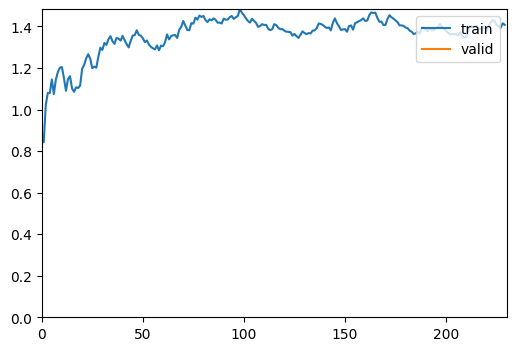

epoch,train_loss,valid_loss,f1_score,time
0,1.027336,0.815447,0.550336,03:01
1,0.931560,0.932580,0.636986,03:04
2,0.970630,0.781744,0.571984,03:05
3,0.925471,0.741728,0.602105,03:06
4,0.876960,0.808660,0.552916,03:07


Better model found at epoch 0 with valid_loss value: 0.8154466152191162.


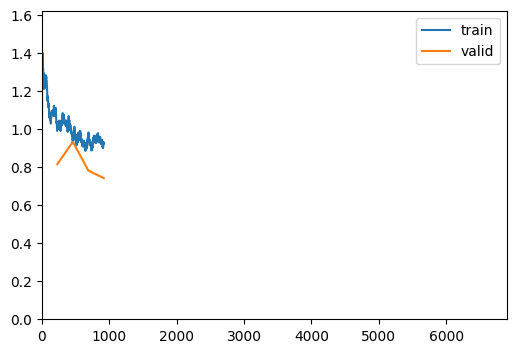

Better model found at epoch 2 with valid_loss value: 0.7817440629005432.
Better model found at epoch 3 with valid_loss value: 0.7417277097702026.
No improvement since epoch 1: early stopping


In [42]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=512,min_scale=0.75))

dls = db.dataloaders(p_under2, bs=8)

callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Hrnet')
]

learn = vision_learner(dls, 'hrnet_w44', metrics=F1Score(), cbs=callbacks).to_fp16()
learn.fine_tune(30, base_lr=1e-3)

In [43]:
learn.model[1] = learn.model[1][:-4]

caracteristicas_train = []
with torch.no_grad():
    for images, labels in dls[0]:
        outputs = learn.model(images)
        caracteristicas_train.extend(outputs)

caracteristicas_test = []
with torch.no_grad():
    for images, labels in dls[1]:
        outputs = learn.model(images)
        caracteristicas_test.extend(outputs)

img_train, img_test = db.splitter(db.get_items(p_under2))

In [44]:
dftrain = creaDF(img_train, caracteristicas_train, dfb2)
dftrain.columns = dftrain.columns.astype(str)
dftest = creaDF(img_test, caracteristicas_test, dfb2)
dftest.columns = dftest.columns.astype(str)

X_train = dftrain.drop(["cancer"], axis=1).copy()
y_train = dftrain.loc[::, "cancer"].copy()

X_test = dftest.drop(["cancer"], axis=1).copy()
y_test = dftest.loc[::, "cancer"].copy()

#### Segundo paso

In [45]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_test), y_test) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 68.91, 62.26)

In [46]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_test), y_test) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 71.2, 60.3)

In [47]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_test), y_test) * 100, 2)
mejorConfiguracion3, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

({'C': 0.001}, 68.7, 57.05)

In [48]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_test), y_test) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.01, 'hidden_layer_sizes': 50}, 98.91, 57.27)

In [49]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_test), y_test) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 100.0, 49.89)

In [50]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_test), y_test) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'entropy', 'max_features': None},
 100.0,
 60.74)

In [51]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_test, y_test)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_test, y_test)
mostrar_resultados("Regresión logística", clasificadores3, X_test, y_test)
mostrar_resultados("Red neuronal", clasificadores4, X_test, y_test)
mostrar_resultados("SVM", clasificadores5, X_test, y_test)
mostrar_resultados("Random Forest", clasificadores6, X_test, y_test)

>  Árbol de Decisión C4.5
>  Accuracy: 62.26

[[142  92]
 [ 82 145]]
              precision    recall  f1-score   support

         0.0       0.63      0.61      0.62       234
         1.0       0.61      0.64      0.62       227

    accuracy                           0.62       461
   macro avg       0.62      0.62      0.62       461
weighted avg       0.62      0.62      0.62       461

>  Árbol de Decisión CART
>  Accuracy: 60.3

[[150  84]
 [ 99 128]]
              precision    recall  f1-score   support

         0.0       0.60      0.64      0.62       234
         1.0       0.60      0.56      0.58       227

    accuracy                           0.60       461
   macro avg       0.60      0.60      0.60       461
weighted avg       0.60      0.60      0.60       461

>  Regresión logística
>  Accuracy: 57.05

[[160  74]
 [124 103]]
              precision    recall  f1-score   support

         0.0       0.56      0.68      0.62       234
         1.0       0.58      0.45 

### Deit

epoch,train_loss,valid_loss,f1_score,time
0,1.197652,0.908286,0.505000,00:48


Better model found at epoch 0 with valid_loss value: 0.9082863330841064.


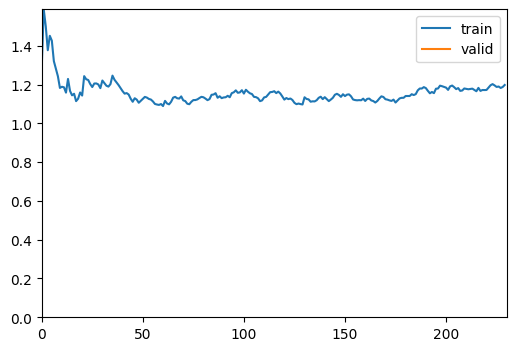

epoch,train_loss,valid_loss,f1_score,time
0,0.894001,0.801977,0.522353,01:07
1,0.868348,0.761913,0.555556,01:09
2,0.786240,0.717379,0.555556,01:10
3,0.812501,0.696294,0.566125,01:11
4,0.766916,0.722999,0.544601,01:12
5,0.767472,0.794514,0.578723,01:12
6,0.712112,0.698952,0.615730,01:11
7,0.650681,0.698958,0.647059,01:10
8,0.660301,0.670803,0.631130,01:11
9,0.607127,0.667956,0.617169,01:13


Better model found at epoch 0 with valid_loss value: 0.8019767999649048.


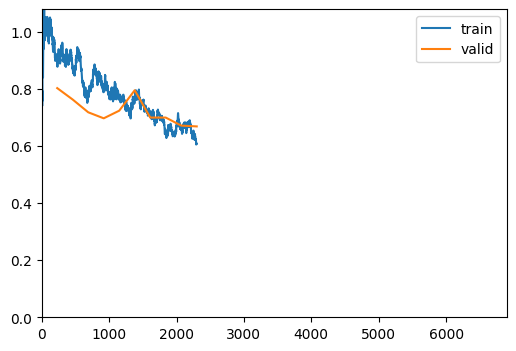

Better model found at epoch 1 with valid_loss value: 0.7619132995605469.
Better model found at epoch 2 with valid_loss value: 0.7173792123794556.
Better model found at epoch 3 with valid_loss value: 0.696293830871582.
Better model found at epoch 8 with valid_loss value: 0.6708027124404907.
Better model found at epoch 9 with valid_loss value: 0.6679559350013733.
No improvement since epoch 7: early stopping


In [52]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func3,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=384,min_scale=0.75))

dls = db.dataloaders(p_under2, bs=8)

callbacks = [
    ShowGraphCallback(),
    EarlyStoppingCallback(monitor='f1_score', comp=np.greater, patience=3),
    SaveModelCallback(fname='Deit')
]

learn = vision_learner(dls, 'deit3_base_patch16_384', metrics=F1Score(), cbs=callbacks).to_fp16()
learn.fine_tune(30, base_lr=1e-3)

In [53]:
learn.model[1] = learn.model[1][:-2]

caracteristicas_train = []
with torch.no_grad():
    for images, labels in dls[0]:
        outputs = learn.model(images)
        caracteristicas_train.extend(outputs)

caracteristicas_test = []
with torch.no_grad():
    for images, labels in dls[1]:
        outputs = learn.model(images)
        caracteristicas_test.extend(outputs)

img_train, img_test = db.splitter(db.get_items(p_under2))

In [54]:
dftrain = creaDF(img_train, caracteristicas_train, dfb2)
dftrain.columns = dftrain.columns.astype(str)
dftest = creaDF(img_test, caracteristicas_test, dfb2)
dftest.columns = dftest.columns.astype(str)

X_train = dftrain.drop(["cancer"], axis=1).copy()
y_train = dftrain.loc[::, "cancer"].copy()

X_test = dftest.drop(["cancer"], axis=1).copy()
y_test = dftest.loc[::, "cancer"].copy()

#### Segundo paso

In [55]:
arbolC45 = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores1 =  model_selection.GridSearchCV(arbolC45, param_grid, scoring = 'accuracy')
clasificadores1.fit(X_train, y_train.values.ravel())
mejorConfiguracion1 = clasificadores1.best_params_
accTrain = round(metrics.accuracy_score(clasificadores1.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores1.predict(X_test), y_test) * 100, 2)
mejorConfiguracion1, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 20}, 68.8, 63.56)

In [56]:
arbolCART = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
param_grid = {'max_depth': [5, 10, None], 'min_samples_split': [2, 10, 20]}
clasificadores2 =  model_selection.GridSearchCV(arbolCART, param_grid, scoring = 'accuracy')
clasificadores2.fit(X_train, y_train.values.ravel())
mejorConfiguracion2 = clasificadores2.best_params_
accTrain = round(metrics.accuracy_score(clasificadores2.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores2.predict(X_test), y_test) * 100, 2)
mejorConfiguracion2, accTrain, accTest

({'max_depth': 5, 'min_samples_split': 2}, 71.9, 62.91)

In [57]:
regresionLogistica = LogisticRegression()
param_grid = {'C': [0.001, 0.01, 0.1, 1]}
clasificadores3 =  model_selection.GridSearchCV(regresionLogistica, param_grid, scoring = 'accuracy')
clasificadores3.fit(X_train, y_train.values.ravel())
mejorConfiguracion3 = clasificadores3.best_params_
accTrain = round(metrics.accuracy_score(clasificadores3.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores3.predict(X_test), y_test) * 100, 2)
mejorConfiguracion3, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

({'C': 0.001}, 65.65, 58.35)

In [58]:
redNeuronal = MLPClassifier(random_state = 0)
param_grid = {'hidden_layer_sizes': [10, 25, 50, 100], 'alpha': [0.0001, 0.001, 0.01, 0.1]}
clasificadores4 =  model_selection.GridSearchCV(redNeuronal, param_grid, scoring = 'accuracy')
clasificadores4.fit(X_train, y_train.values.ravel())
mejorConfiguracion4 = clasificadores4.best_params_
accTrain = round(metrics.accuracy_score(clasificadores4.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores4.predict(X_test), y_test) * 100, 2)
mejorConfiguracion4, accTrain, accTest

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

({'alpha': 0.1, 'hidden_layer_sizes': 50}, 100.0, 57.05)

In [59]:
SVM = SVC(gamma = "auto", random_state = 0)
param_grid = {'decision_function_shape': ['ovo', 'ovr']}
clasificadores5 =  model_selection.GridSearchCV(SVM, param_grid, scoring = 'accuracy')
clasificadores5.fit(X_train, y_train.values.ravel())
mejorConfiguracion5 = clasificadores5.best_params_
accTrain = round(metrics.accuracy_score(clasificadores5.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores5.predict(X_test), y_test) * 100, 2)
mejorConfiguracion5, accTrain, accTest

({'decision_function_shape': 'ovo'}, 78.91, 59.65)

In [60]:
rf = RandomForestClassifier(random_state = 0)
param_grid = {'criterion':["gini", "entropy"],'max_features':["sqrt", "log2", None], 'bootstrap': [True, False]}
clasificadores6 =  model_selection.GridSearchCV(rf, param_grid, scoring = 'accuracy')
clasificadores6.fit(X_train, y_train.values.ravel())
mejorConfiguracion6 = clasificadores6.best_params_
accTrain = round(metrics.accuracy_score(clasificadores6.predict(X_train), y_train) * 100, 2)
accTest =  round(metrics.accuracy_score(clasificadores6.predict(X_test), y_test) * 100, 2)
mejorConfiguracion6, accTrain, accTest

({'bootstrap': True, 'criterion': 'entropy', 'max_features': None},
 100.0,
 59.65)

In [61]:
mostrar_resultados("Árbol de Decisión C4.5", clasificadores1, X_test, y_test)
mostrar_resultados("Árbol de Decisión CART", clasificadores2, X_test, y_test)
mostrar_resultados("Regresión logística", clasificadores3, X_test, y_test)
mostrar_resultados("Red neuronal", clasificadores4, X_test, y_test)
mostrar_resultados("SVM", clasificadores5, X_test, y_test)
mostrar_resultados("Random Forest", clasificadores6, X_test, y_test)

>  Árbol de Decisión C4.5
>  Accuracy: 63.56

[[151  83]
 [ 85 142]]
              precision    recall  f1-score   support

         0.0       0.64      0.65      0.64       234
         1.0       0.63      0.63      0.63       227

    accuracy                           0.64       461
   macro avg       0.64      0.64      0.64       461
weighted avg       0.64      0.64      0.64       461

>  Árbol de Decisión CART
>  Accuracy: 62.91

[[138  96]
 [ 75 152]]
              precision    recall  f1-score   support

         0.0       0.65      0.59      0.62       234
         1.0       0.61      0.67      0.64       227

    accuracy                           0.63       461
   macro avg       0.63      0.63      0.63       461
weighted avg       0.63      0.63      0.63       461

>  Regresión logística
>  Accuracy: 58.35

[[130 104]
 [ 88 139]]
              precision    recall  f1-score   support

         0.0       0.60      0.56      0.58       234
         1.0       0.57      0.61